# Clasificación y relevancia de variables — Sprint 3

---

## Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Importaciones y configuración global |
| 1 | Carga y preparación de datos |
| **EXP 1** | Todas las posiciones — 6 clases |
| **EXP 2** | Posiciones agrupadas (LW+RW→Wing, LB+RB→Lateral) — 4 clases |
| Final | Entrenamiento sobre el dataset completo (train+test) para modelo robusto |

## 0. Importaciones y configuración

In [268]:
#Para solo ejecutar el experimento 2, para ajustar parametros
SOLO_EXP2 = False

import os, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    train_test_split, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
import xgboost as xgb
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

# ── Directorios de salida ────────────────────────────────────
OUT_ROOT = 'position_output'
for d in [OUT_ROOT, f'{OUT_ROOT}/exp1', f'{OUT_ROOT}/exp2', f'{OUT_ROOT}/final']:
    os.makedirs(d, exist_ok=True)

# ── Paleta de colores ────────────────────────────────────────
POS_COLORS = {
    'LW': '#3266ad', 'RW': '#7f77dd',
    'LB': '#d85a30', 'RB': '#ba7517',
    'CB': '#1d9e75',
    'LP': '#d4537e',
    # Grupos (Exp 2)
    'Wing':    '#3266ad',
    'Lateral': '#d85a30',
    'Central': '#1d9e75',
    'Pivote':  '#d4537e',
}

RANDOM_STATE = 52
print('Configuración lista.')

Configuración lista.


## 1. Carga y preparación de datos

In [269]:
ruta_csv = 'EHF2024-W-AGGREGATED.csv'
df_raw = pd.read_csv(ruta_csv)

# ── Variables excluidas
COLS_DROP = ['Unnamed: 0', 'Team', 'No', 'Name',
             'scoring', 'topk', 'top1', 'R7', 'P7',
             'RC', 'Time', '2+2']          # <-- eliminadas según requisito

FEATURE_COLS = [
    '7mPGoals', '7mPMissed',
    '6mCGoals', '6mCMissed',
    'WingGoals', 'WingMissed',
    'BTGoals',  'BTMissed',
    'FBGoals',  'FBMissed',
    'FTOGoals', 'FTOMissed',
    '9mGoals',  '9mMissed',
    '2M', 'AS', 'ST', 'BS', 'TO'
]
TARGET_COL = 'Position'

df_full = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
df_full[TARGET_COL] = df_full[TARGET_COL].astype(str).str.strip()
df_full = df_full.dropna()

print(f'Dataset completo: {df_full.shape[0]} jugadores, {len(FEATURE_COLS)} variables')
print('\nDistribución original de posiciones:')
print(df_full[TARGET_COL].value_counts())

Dataset completo: 414 jugadores, 19 variables

Distribución original de posiciones:
Position
LB    84
LP    64
GK    63
CB    58
LW    51
RB    50
RW    44
Name: count, dtype: int64


---

# ══════════════════════════════════════════
# EXPERIMENTO 1 — Todas las posiciones
# (LW, RW, LB, RB, CB, LP — 6 clases)
# ══════════════════════════════════════════

In [270]:
if not SOLO_EXP2:
    # ── Filtrar porteros ─────────────────────────────────────────
    df_exp1 = df_full[df_full[TARGET_COL] != 'GK'].copy()
    print(f'[EXP 1] Jugadores tras eliminar GK: {len(df_exp1)}')
    print(df_exp1[TARGET_COL].value_counts())
    
    X1 = df_exp1[FEATURE_COLS].values
    y1_raw = df_exp1[TARGET_COL].values
    
    le1 = LabelEncoder()
    y1 = le1.fit_transform(y1_raw)
    print('\nClases EXP 1:', le1.classes_)


[EXP 1] Jugadores tras eliminar GK: 351
Position
LB    84
LP    64
CB    58
LW    51
RB    50
RW    44
Name: count, dtype: int64

Clases EXP 1: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']


### 1.1 Split 80/20 estratificado + Estandarización z-score

In [271]:
if not SOLO_EXP2:
    # IMPORTANTE: split PRIMERO, estandarización DESPUÉS (solo fit en train) par evitar fuga de datos
    X1_train, X1_test, y1_train, y1_test = train_test_split(
        X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
    )
    
    scaler1 = StandardScaler()              # z-score
    X1_train_sc = scaler1.fit_transform(X1_train)   # fit solo en train
    X1_test_sc  = scaler1.transform(X1_test)        # transform en test
    
    print(f'Train: {X1_train_sc.shape[0]}  |  Test: {X1_test_sc.shape[0]}')


Train: 280  |  Test: 71


### 1.2 Funciones auxiliares

In [272]:
def metrics_table(y_true, y_pred, label_encoder, model_name, cv_mean=None, cv_std=None, train_acc=None):
    """Devuelve DataFrame con métricas globales por modelo."""
    acc   = accuracy_score(y_true, y_pred)
    f1_w  = f1_score(y_true, y_pred, average='weighted')
    f1_m  = f1_score(y_true, y_pred, average='macro')
    prec  = precision_score(y_true, y_pred, average='weighted')
    rec   = recall_score(y_true, y_pred, average='weighted')
    row = {
        'Modelo': model_name,
        'Accuracy': round(acc, 4),
        'F1 (weighted)': round(f1_w, 4),
        'F1 (macro)': round(f1_m, 4),
        'Precision (weighted)': round(prec, 4),
        'Recall (weighted)': round(rec, 4),
    }
    if train_acc is not None:
        row['Train Accuracy'] = round(train_acc, 4)
    if cv_mean is not None:
        row['CV Accuracy (mean)'] = round(cv_mean, 4)
        row['CV Accuracy (std)']  = round(cv_std, 4)
    if train_acc is not None and cv_mean is not None:
        row['Diferencia (Train-CV)'] = round(train_acc - cv_mean, 4)
    return row


def per_class_table(y_true, y_pred, label_encoder, model_name):
    """Tabla de métricas por clase."""
    report = classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    rows = []
    for cls in label_encoder.classes_:
        rows.append({
            'Modelo': model_name,
            'Clase': cls,
            'Precision': round(report[cls]['precision'], 4),
            'Recall':    round(report[cls]['recall'],    4),
            'F1-score':  round(report[cls]['f1-score'],  4),
        })
    return rows


def save_confusion_matrix(y_true, y_pred, label_encoder, model_name, filepath):
    """Guarda la matriz de confusión como imagen PNG."""
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{model_name}  (acc={acc:.3f})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {filepath}')


cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 1.3 Random Forest + GridSearchCV

In [273]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200, 300, 350, 400],
    'max_depth':         [None, 3, 7, 10, 15, 20],
    'min_samples_leaf':  [1, 2, 3, 5],
    'min_samples_split': [2, 3, 4, 5],
    'max_features':      [None, 'sqrt', 'log2']
}

if not SOLO_EXP2:
    
    
    
    rf_base = RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    gs_rf1 = GridSearchCV(
        rf_base, param_grid_rf, cv=cv5,
        scoring='accuracy', n_jobs=-1, verbose=0
    )
    gs_rf1.fit(X1_train_sc, y1_train)
    rf1 = gs_rf1.best_estimator_
    
    print(f'[EXP1 RF] Mejores hiperparámetros: {gs_rf1.best_params_}')
    print(f'[EXP1 RF] CV accuracy (best):      {gs_rf1.best_score_:.4f}')

    
    
    y1_pred_rf = rf1.predict(X1_test_sc)
    
    # Train accuracy y CV en train con el mejor estimador
    train_acc_rf1 = accuracy_score(y1_train, rf1.predict(X1_train_sc))

    pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', rf1)
    ])
    
    cv_rf1 = cross_val_score(pipeline_rf, X1_train, y1_train, cv=cv5, scoring='accuracy')
    
    print(f'[EXP1 RF] Train accuracy: {train_acc_rf1:.4f}')
    print(f'[EXP1 RF] Test accuracy:  {accuracy_score(y1_test, y1_pred_rf):.4f}')
    print(f'[EXP1 RF] Diferencia Train-Test: {train_acc_rf1 - accuracy_score(y1_test, y1_pred_rf):.4f}')
    print(classification_report(y1_test, y1_pred_rf, target_names=le1.classes_))


[EXP1 RF] Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
[EXP1 RF] CV accuracy (best):      0.5286
[EXP1 RF] Train accuracy: 0.9179
[EXP1 RF] Test accuracy:  0.6197
[EXP1 RF] Diferencia Train-Test: 0.2981
              precision    recall  f1-score   support

          CB       0.53      0.67      0.59        12
          LB       0.67      0.59      0.62        17
          LP       0.76      1.00      0.87        13
          LW       0.58      0.70      0.64        10
          RB       0.40      0.20      0.27        10
          RW       0.57      0.44      0.50         9

    accuracy                           0.62        71
   macro avg       0.59      0.60      0.58        71
weighted avg       0.60      0.62      0.60        71



### 1.4 XGBoost + GridSearchCV

In [274]:
param_grid_xgb = {
    'n_estimators':      [5, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 300, 500],
    'max_depth':         [2, 3, 4, 5, 6, 7, 10],                                
    'colsample_bytree':  [0.4, 0.5, 0.7, 0.8, 0.9, 1],            
    'reg_alpha':         [0.4, 0.5, 0.7, 0.8, 0.9, 1],
    'min_child_weight':  [1, 2, 4, 5],
}

if not SOLO_EXP2:
    
    
    
    xgb_base = xgb.XGBClassifier(
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    gs_xgb1 = GridSearchCV(
        xgb_base, param_grid_xgb, cv=cv5,
        scoring='accuracy', n_jobs=-1, verbose=0
    )
    gs_xgb1.fit(X1_train_sc, y1_train)
    xgb1 = gs_xgb1.best_estimator_
    
    print(f'[EXP1 XGB] Mejores hiperparámetros: {gs_xgb1.best_params_}')
    print(f'[EXP1 XGB] CV accuracy (best):      {gs_xgb1.best_score_:.4f}')
    
    y1_pred_xgb = xgb1.predict(X1_test_sc)
    train_acc_xgb1 = accuracy_score(y1_train, xgb1.predict(X1_train_sc))

    pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb1)
    ])

    cv_xgb1 = cross_val_score(pipeline_xgb, X1_train, y1_train, cv=cv5, scoring='accuracy')
    
    print(f'[EXP1 XGB] Train accuracy: {train_acc_xgb1:.4f}')
    print(f'[EXP1 XGB] Test accuracy:  {accuracy_score(y1_test, y1_pred_xgb):.4f}')
    print(f'[EXP1 XGB] Diferencia Train-Test: {train_acc_xgb1 - accuracy_score(y1_test, y1_pred_xgb):.4f}')
    print(classification_report(y1_test, y1_pred_xgb, target_names=le1.classes_))


[EXP1 XGB] Mejores hiperparámetros: {'colsample_bytree': 0.5, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 30, 'reg_alpha': 1}
[EXP1 XGB] CV accuracy (best):      0.5429
[EXP1 XGB] Train accuracy: 0.9107
[EXP1 XGB] Test accuracy:  0.6479
[EXP1 XGB] Diferencia Train-Test: 0.2628
              precision    recall  f1-score   support

          CB       0.58      0.58      0.58        12
          LB       0.72      0.76      0.74        17
          LP       0.81      1.00      0.90        13
          LW       0.58      0.70      0.64        10
          RB       0.33      0.20      0.25        10
          RW       0.57      0.44      0.50         9

    accuracy                           0.65        71
   macro avg       0.60      0.62      0.60        71
weighted avg       0.62      0.65      0.63        71



### 1.5 SVM + GridSearchCV

In [275]:
param_grid_svm = {
    'C':      [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0, 50.0, 100.0],
    'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
    'kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
}

if not SOLO_EXP2:
    
    svm_base = SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True)
    gs_svm1 = GridSearchCV(
        svm_base, param_grid_svm, cv=cv5,
        scoring='accuracy', n_jobs=-1, verbose=0
    )
    gs_svm1.fit(X1_train_sc, y1_train)
    svm1 = gs_svm1.best_estimator_
    
    print(f'[EXP1 SVM] Mejores hiperparámetros: {gs_svm1.best_params_}')
    print(f'[EXP1 SVM] CV accuracy (best):      {gs_svm1.best_score_:.4f}')
    
    y1_pred_svm = svm1.predict(X1_test_sc)
    train_acc_svm1 = accuracy_score(y1_train, svm1.predict(X1_train_sc))

    pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', svm1)
    ])

    cv_svm1 = cross_val_score(pipeline_svm, X1_train, y1_train, cv=cv5, scoring='accuracy')
    
    print(f'[EXP1 SVM] Train accuracy: {train_acc_svm1:.4f}')
    print(f'[EXP1 SVM] Test accuracy:  {accuracy_score(y1_test, y1_pred_svm):.4f}')
    print(f'[EXP1 SVM] Diferencia Train-Test: {train_acc_svm1 - accuracy_score(y1_test, y1_pred_svm):.4f}')
    print(classification_report(y1_test, y1_pred_svm, target_names=le1.classes_))


[EXP1 SVM] Mejores hiperparámetros: {'C': 50.0, 'gamma': 'auto', 'kernel': 'rbf'}
[EXP1 SVM] CV accuracy (best):      0.5464
[EXP1 SVM] Train accuracy: 0.9000
[EXP1 SVM] Test accuracy:  0.4507
[EXP1 SVM] Diferencia Train-Test: 0.4493
              precision    recall  f1-score   support

          CB       0.45      0.42      0.43        12
          LB       0.42      0.29      0.34        17
          LP       0.59      0.77      0.67        13
          LW       0.57      0.40      0.47        10
          RB       0.24      0.40      0.30        10
          RW       0.57      0.44      0.50         9

    accuracy                           0.45        71
   macro avg       0.47      0.45      0.45        71
weighted avg       0.47      0.45      0.45        71



### 1.6 Red Neuronal (MLP) + GridSearchCV

In [276]:
param_grid_mlp = {
    'hidden_layer_sizes': [
        (32,),
        (64,),
        (32, 16),
        (64, 32),
        (128, 64),
        (256, 128),
        (128, 64, 32),
        (256, 128, 64),
        (512, 256, 128),
        (512, 256, 128, 64),
        (512, 256, 128, 64, 32),
        (1024, 512, 256, 128, 64, 32)
    ],
    'activation':         ['relu', 'tanh'],
    'alpha':              [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
    'learning_rate_init': [0.0001, 0.0005, 0.001, 0.005],
    'learning_rate':      ['adaptive', 'constant'],
}

if not SOLO_EXP2:
    
    mlp_base = MLPClassifier(
        max_iter=500, early_stopping=True,
        random_state=RANDOM_STATE
    )
    gs_mlp1 = GridSearchCV(
        mlp_base, param_grid_mlp, cv=cv5,
        scoring='accuracy', n_jobs=-1, verbose=0
    )
    gs_mlp1.fit(X1_train_sc, y1_train)
    mlp1 = gs_mlp1.best_estimator_
    
    print(f'[EXP1 MLP] Mejores hiperparámetros: {gs_mlp1.best_params_}')
    print(f'[EXP1 MLP] CV accuracy (best):      {gs_mlp1.best_score_:.4f}')
    
    y1_pred_mlp = mlp1.predict(X1_test_sc)
    train_acc_mlp1 = accuracy_score(y1_train, mlp1.predict(X1_train_sc))

    pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', mlp1)
    ])
    
    cv_mlp1 = cross_val_score(pipeline_mlp, X1_train, y1_train, cv=cv5, scoring='accuracy')
    
    print(f'[EXP1 MLP] Train accuracy: {train_acc_mlp1:.4f}')
    print(f'[EXP1 MLP] Test accuracy:  {accuracy_score(y1_test, y1_pred_mlp):.4f}')
    print(f'[EXP1 MLP] Diferencia Train-Test: {train_acc_mlp1 - accuracy_score(y1_test, y1_pred_mlp):.4f}')
    print(classification_report(y1_test, y1_pred_mlp, target_names=le1.classes_))


[EXP1 MLP] Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (512, 256, 128, 64), 'learning_rate': 'adaptive', 'learning_rate_init': 0.005}
[EXP1 MLP] CV accuracy (best):      0.4821
[EXP1 MLP] Train accuracy: 0.5464
[EXP1 MLP] Test accuracy:  0.4930
[EXP1 MLP] Diferencia Train-Test: 0.0535
              precision    recall  f1-score   support

          CB       0.67      0.17      0.27        12
          LB       0.41      0.94      0.57        17
          LP       0.88      0.54      0.67        13
          LW       0.47      0.90      0.62        10
          RB       0.00      0.00      0.00        10
          RW       0.50      0.11      0.18         9

    accuracy                           0.49        71
   macro avg       0.49      0.44      0.38        71
weighted avg       0.50      0.49      0.41        71



### 1.7 Matrices de confusión (imágenes)

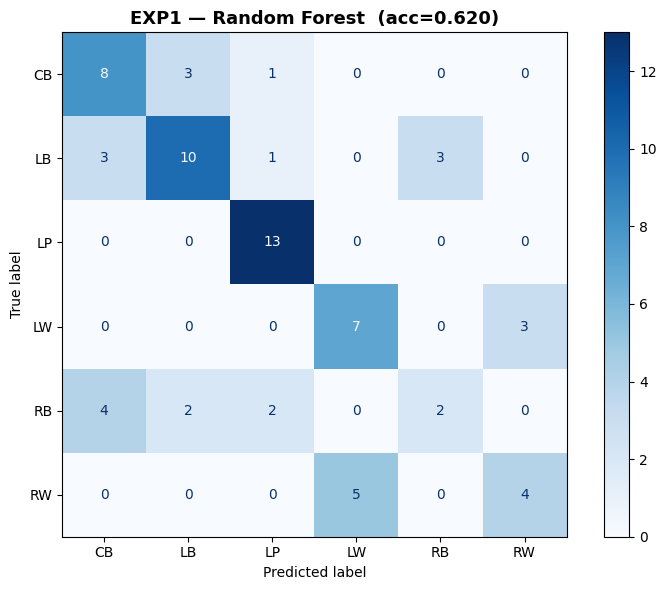

Guardada: position_output/exp1/cm_random_forest.png


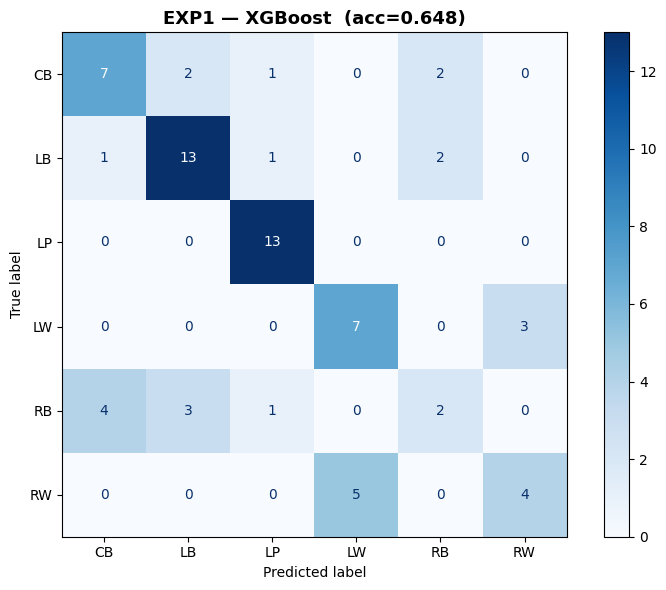

Guardada: position_output/exp1/cm_xgboost.png


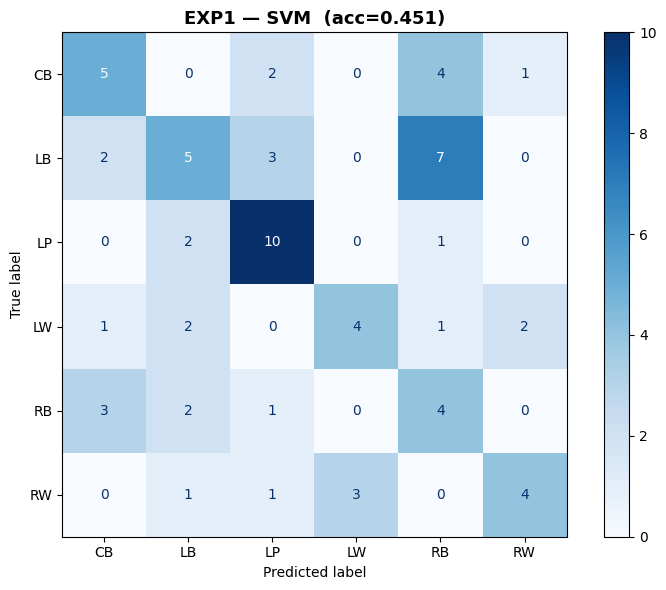

Guardada: position_output/exp1/cm_svm.png


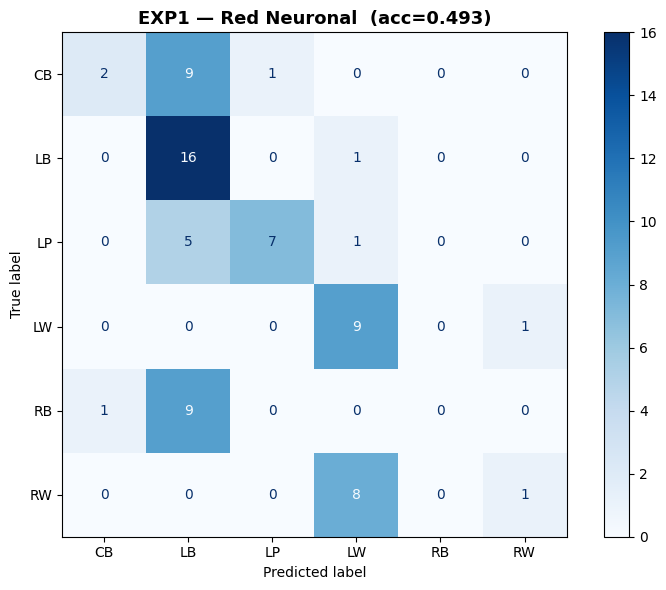

Guardada: position_output/exp1/cm_red_neuronal.png


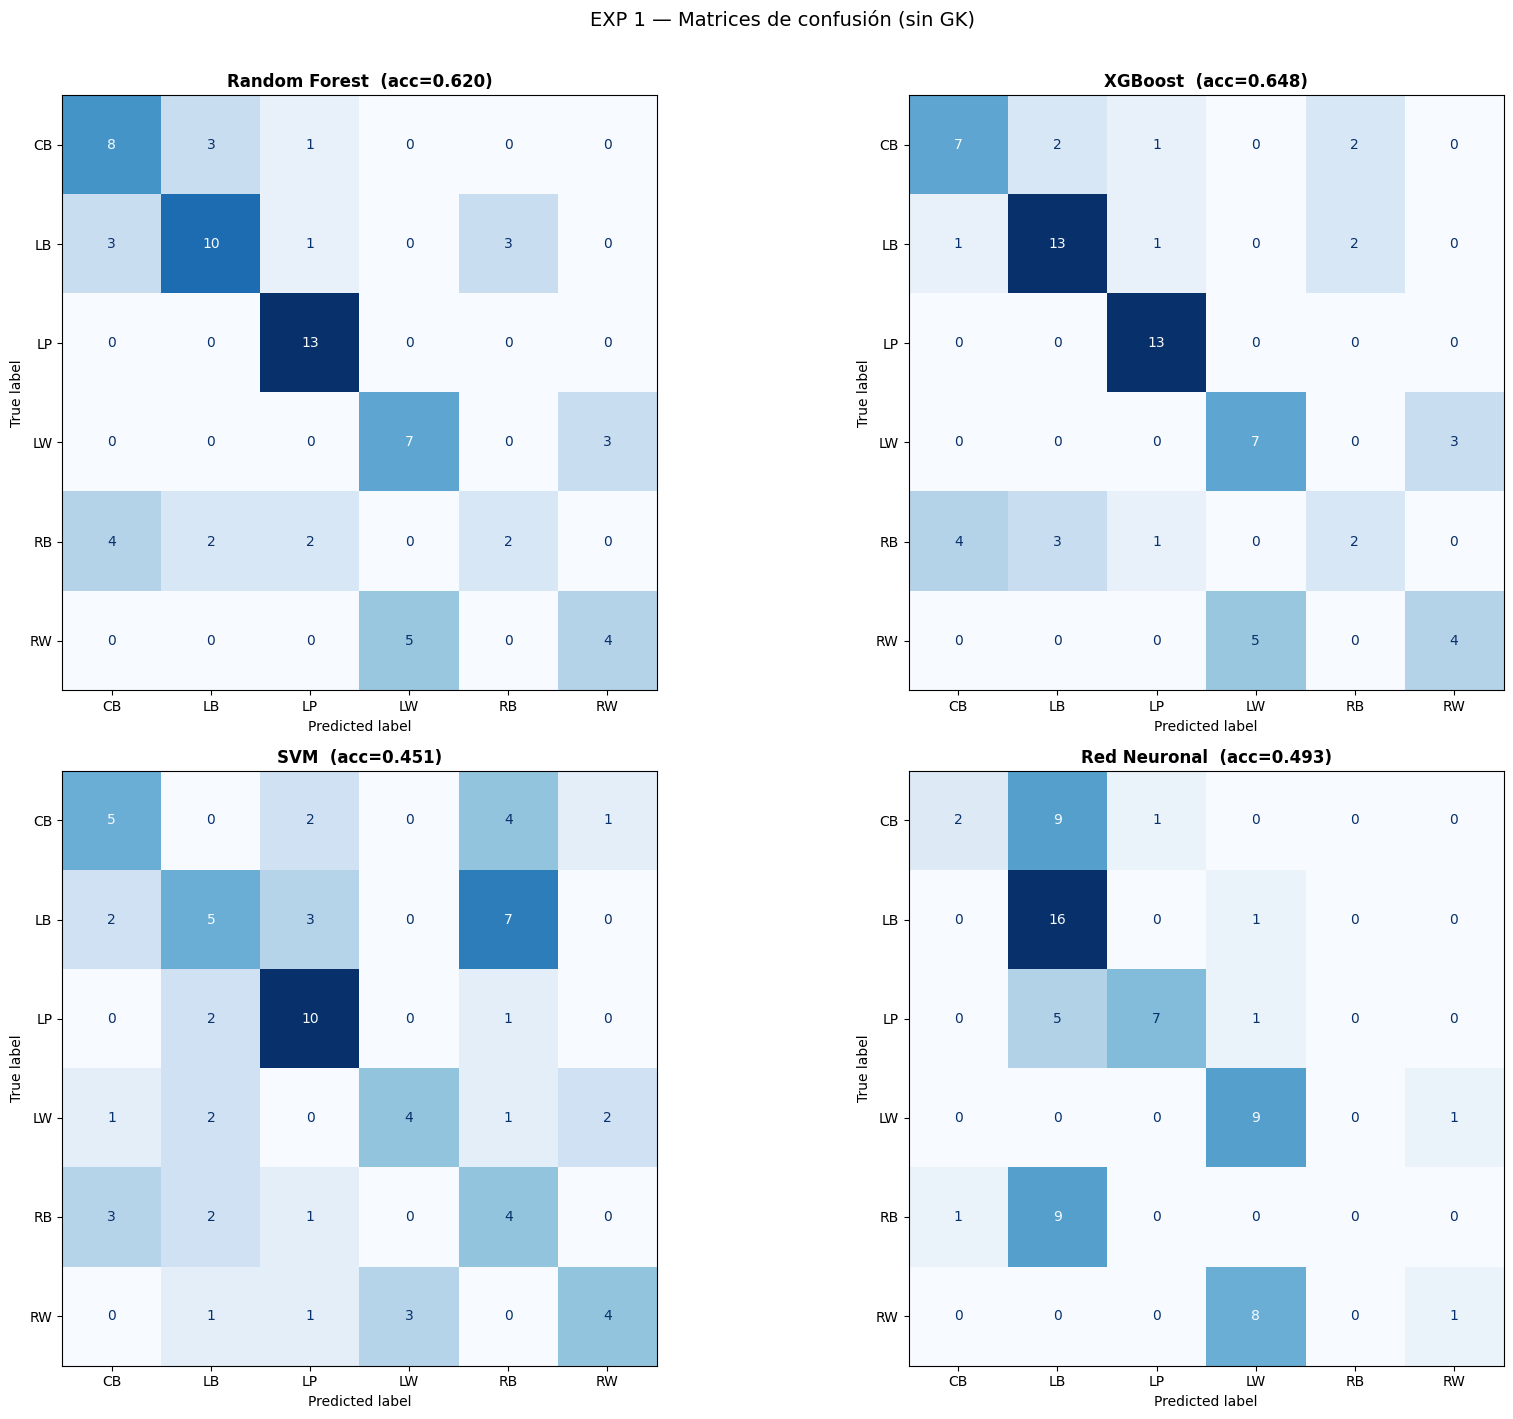

Guardada figura combinada: position_output/exp1/confusion_matrices_all.png


In [277]:
if not SOLO_EXP2:
    models_exp1 = [
        ('Random Forest', y1_pred_rf),
        ('XGBoost',       y1_pred_xgb),
        ('SVM',           y1_pred_svm),
        ('Red Neuronal',  y1_pred_mlp),
    ]
    
    for name, preds in models_exp1:
        path = f"{OUT_ROOT}/exp1/cm_{name.replace(' ','_').lower()}.png"
        save_confusion_matrix(y1_test, preds, le1, f'EXP1 — {name}', path)
    
    # Figura combinada de las 4 matrices
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    for ax, (name, preds) in zip(axes, models_exp1):
        cm = confusion_matrix(y1_test, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=le1.classes_)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        acc = accuracy_score(y1_test, preds)
        ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
    plt.suptitle('EXP 1 — Matrices de confusión (sin GK)', fontsize=14, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Guardada figura combinada: {OUT_ROOT}/exp1/confusion_matrices_all.png")


### 1.8 Tabla de métricas — EXP 1

In [278]:
if not SOLO_EXP2:
    train_accs1 = [train_acc_rf1, train_acc_xgb1, train_acc_svm1, train_acc_mlp1]
    cvs1 = [
        (cv_rf1.mean(),  cv_rf1.std()),
        (cv_xgb1.mean(), cv_xgb1.std()),
        (cv_svm1.mean(), cv_svm1.std()),
        (cv_mlp1.mean(), cv_mlp1.std()),
    ]
    
    rows_exp1 = []
    for (name, preds), (cv_m, cv_s), tr_acc in zip(models_exp1, cvs1, train_accs1):
        rows_exp1.append(metrics_table(y1_test, preds, le1, name, cv_m, cv_s, tr_acc))
    
    df_metrics_exp1 = pd.DataFrame(rows_exp1).set_index('Modelo')
    # Reordenar columnas para lectura intuitiva
    col_order1 = ['Train Accuracy', 'CV Accuracy (mean)', 'CV Accuracy (std)',
                  'Accuracy', 'Diferencia (Train-CV)', 'F1 (weighted)', 'F1 (macro)',
                  'Precision (weighted)', 'Recall (weighted)']
    df_metrics_exp1 = df_metrics_exp1[[c for c in col_order1 if c in df_metrics_exp1.columns]]
    print('=== EXP 1 — Métricas globales (con Comprobación de sobreajuste) ===')
    display(df_metrics_exp1.style.background_gradient(subset=['Diferencia (Train-CV)'], cmap='RdYlGn_r'))
    df_metrics_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_global.csv')
    
    # Tabla por clase
    rows_class_exp1 = []
    for name, preds in models_exp1:
        rows_class_exp1.extend(per_class_table(y1_test, preds, le1, name))
    df_class_exp1 = pd.DataFrame(rows_class_exp1)
    print('\n=== EXP 1 — Métricas por clase ===')
    display(df_class_exp1)
    df_class_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_per_class.csv', index=False)


=== EXP 1 — Métricas globales (con Comprobación de sobreajuste) ===


,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Accuracy,Diferencia (Train-CV),F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,,,,,
Random Forest,0.917900,0.525000,0.050000,0.619700,0.392900,0.599100,0.581200,0.600700,0.619700
XGBoost,0.910700,0.542900,0.024200,0.647900,0.367900,0.628800,0.601500,0.621800,0.647900
SVM,0.900000,0.542900,0.033100,0.450700,0.357100,0.449500,0.452200,0.470400,0.450700
Red Neuronal,0.546400,0.450000,0.034600,0.493000,0.096400,0.414400,0.384500,0.501200,0.493000



=== EXP 1 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,CB,0.5333,0.6667,0.5926
1,Random Forest,LB,0.6667,0.5882,0.6250
2,Random Forest,LP,0.7647,1.0000,0.8667
3,Random Forest,LW,0.5833,0.7000,0.6364
4,Random Forest,RB,0.4000,0.2000,0.2667
5,Random Forest,RW,0.5714,0.4444,0.5000
6,XGBoost,CB,0.5833,0.5833,0.5833
7,XGBoost,LB,0.7222,0.7647,0.7429
8,XGBoost,LP,0.8125,1.0000,0.8966
9,XGBoost,LW,0.5833,0.7000,0.6364


### 1.10 Comprobacion de sobreajuste — EXP 1

Comparamos **Train Accuracy**, **CV Accuracy (5-fold sobre train)** y **Test Accuracy** para detectar sobreajuste:

Se añaden también las **curvas de aprendizaje** para ver cómo evoluciona la brecha al variar el tamaño de entrenamiento.

=== EXP 1 — Comprobación de sobreajuste ===


,Train Accuracy,CV Accuracy (mean),CV Std (±),Test Accuracy,Diferencia Train-CV,Diferencia Train-Test
Modelo,,,,,,
Random Forest,0.917900,0.525000,0.050000,0.619700,0.392900,0.298100
XGBoost,0.910700,0.542900,0.024200,0.647900,0.367900,0.262800
SVM,0.900000,0.542900,0.033100,0.450700,0.357100,0.449300
Red Neuronal,0.546400,0.450000,0.034600,0.493000,0.096400,0.053500


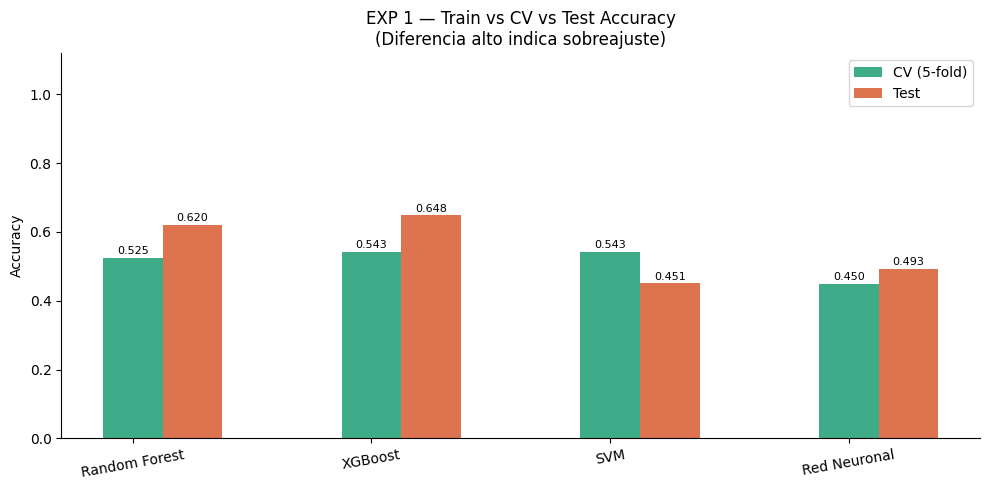

Guardada: position_output/exp1/overfit_train_cv_test.png


In [279]:
if not SOLO_EXP2:
    # ── Tabla resumen Train / CV / Test ─────────────────────────
    models_exp1_dict = {
        'Random Forest': (rf1,  train_acc_rf1,  cv_rf1,  y1_pred_rf),
        'XGBoost':       (xgb1, train_acc_xgb1, cv_xgb1, y1_pred_xgb),
        'SVM':           (svm1, train_acc_svm1, cv_svm1, y1_pred_svm),
        'Red Neuronal':  (mlp1, train_acc_mlp1, cv_mlp1, y1_pred_mlp),
    }
    
    overfit_rows1 = []
    for mname, (model, tr_acc, cv_scores, preds) in models_exp1_dict.items():
        test_acc = accuracy_score(y1_test, preds)
        overfit_rows1.append({
            'Modelo':            mname,
            'Train Accuracy':    round(tr_acc, 4),
            'CV Accuracy (mean)':round(cv_scores.mean(), 4),
            'CV Std (±)':        round(cv_scores.std(), 4),
            'Test Accuracy':     round(test_acc, 4),
            'Diferencia Train-CV':      round(tr_acc - cv_scores.mean(), 4),
            'Diferencia Train-Test':    round(tr_acc - test_acc, 4),
        })
    
    df_overfit1 = pd.DataFrame(overfit_rows1).set_index('Modelo')
    print('=== EXP 1 — Comprobación de sobreajuste ===')
    display(df_overfit1.style.background_gradient(subset=['Diferencia Train-CV', 'Diferencia Train-Test'],
                                                   cmap='RdYlGn_r'))
    df_overfit1.to_csv(f'{OUT_ROOT}/exp1/overfit_diagnosis.csv')
    
    # ── Gráfico: Train vs CV vs Test Accuracy ───────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    x      = np.arange(len(overfit_rows1))
    width  = 0.25
    names  = [r['Modelo'] for r in overfit_rows1]
    tr_vals  = [r['Train Accuracy']     for r in overfit_rows1]
    cv_vals  = [r['CV Accuracy (mean)'] for r in overfit_rows1]
    te_vals  = [r['Test Accuracy']      for r in overfit_rows1]
    
    b2 = ax.bar(x, cv_vals, width, label='CV (5-fold)',   color='#1d9e75', alpha=0.85)
    b3 = ax.bar(x + width, te_vals, width, label='Test',          color='#d85a30', alpha=0.85)
    
    for bars in [b2, b3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Accuracy')
    ax.set_title('EXP 1 — Train vs CV vs Test Accuracy\n(Diferencia alto indica sobreajuste)', fontsize=12)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/overfit_train_cv_test.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {OUT_ROOT}/exp1/overfit_train_cv_test.png')


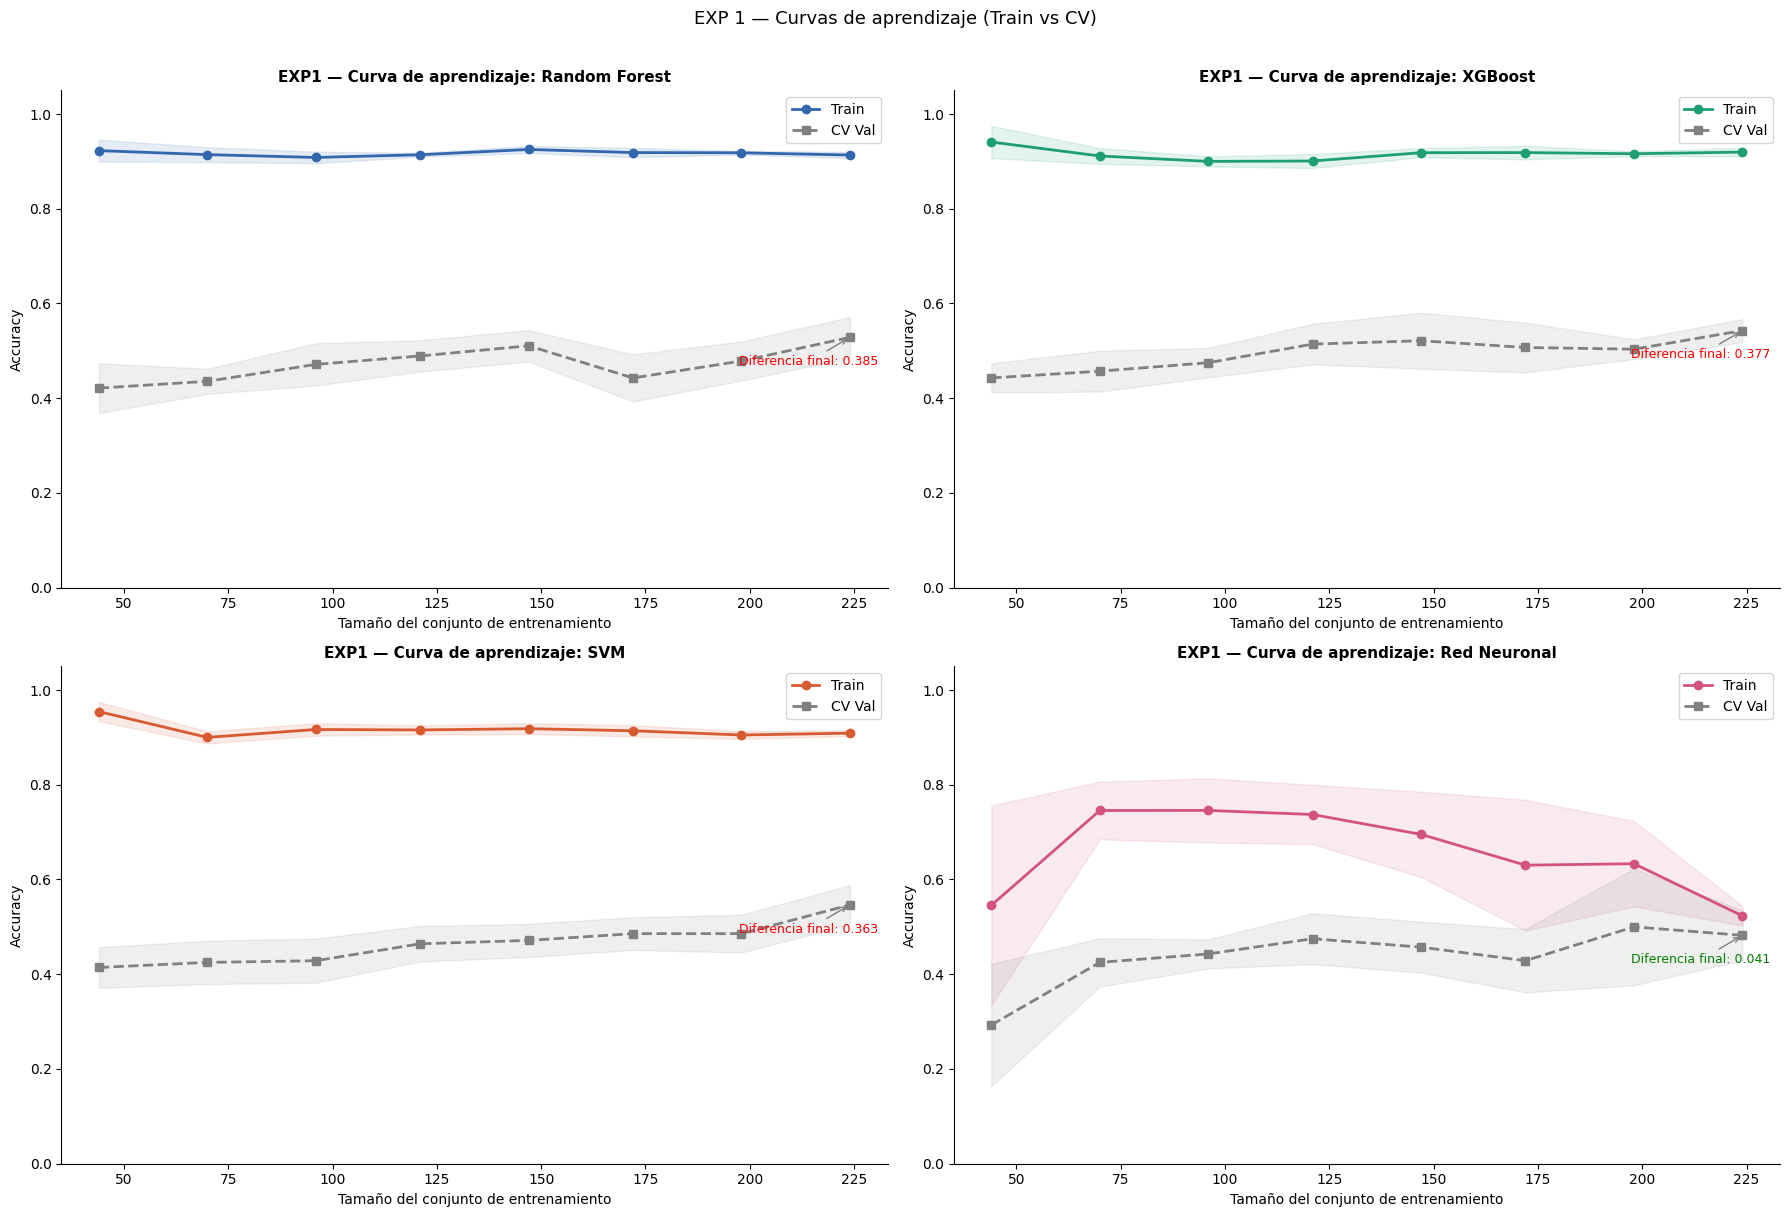

Guardada: position_output/exp1/learning_curves.png


In [280]:
if not SOLO_EXP2:
    # ── Curvas de aprendizaje — EXP 1 ───────────────────────────
    lc_models1 = [
        ('Random Forest', rf1,  '#3266ad'),
        ('XGBoost',       xgb1, '#1d9e75'),
        ('SVM',           svm1, '#d85a30'),
        ('Red Neuronal',  mlp1, '#d4537e'),
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    
    for ax, (mname, model, color) in zip(axes, lc_models1):
        train_sizes, train_scores, val_scores = learning_curve(
            model, X1_train_sc, y1_train,
            cv=cv5, scoring='accuracy',
            train_sizes=np.linspace(0.2, 1.0, 8),
            n_jobs=-1
        )
        tr_mean  = train_scores.mean(axis=1)
        tr_std   = train_scores.std(axis=1)
        val_mean = val_scores.mean(axis=1)
        val_std  = val_scores.std(axis=1)
    
        ax.plot(train_sizes, tr_mean,  'o-', color=color,   label='Train',   linewidth=2)
        ax.plot(train_sizes, val_mean, 's--', color='gray', label='CV Val',  linewidth=2)
        ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
        ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='gray')
        ax.set_xlabel('Tamaño del conjunto de entrenamiento')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'EXP1 — Curva de aprendizaje: {mname}', fontsize=11, fontweight='bold')
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.spines[['top', 'right']].set_visible(False)
        # Anotar Diferencia final
        Diferencia = tr_mean[-1] - val_mean[-1]
        ax.annotate(f'Diferencia final: {Diferencia:.3f}',
                    xy=(train_sizes[-1], val_mean[-1]),
                    xytext=(-80, -20), textcoords='offset points',
                    fontsize=9, color='red' if Diferencia > 0.10 else 'green',
                    arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.suptitle('EXP 1 — Curvas de aprendizaje (Train vs CV)', fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/learning_curves.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {OUT_ROOT}/exp1/learning_curves.png')


### 1.9 Análisis SHAP — EXP 1 (mejor modelo)

Mejor modelo EXP1: XGBoost  (0.6479)


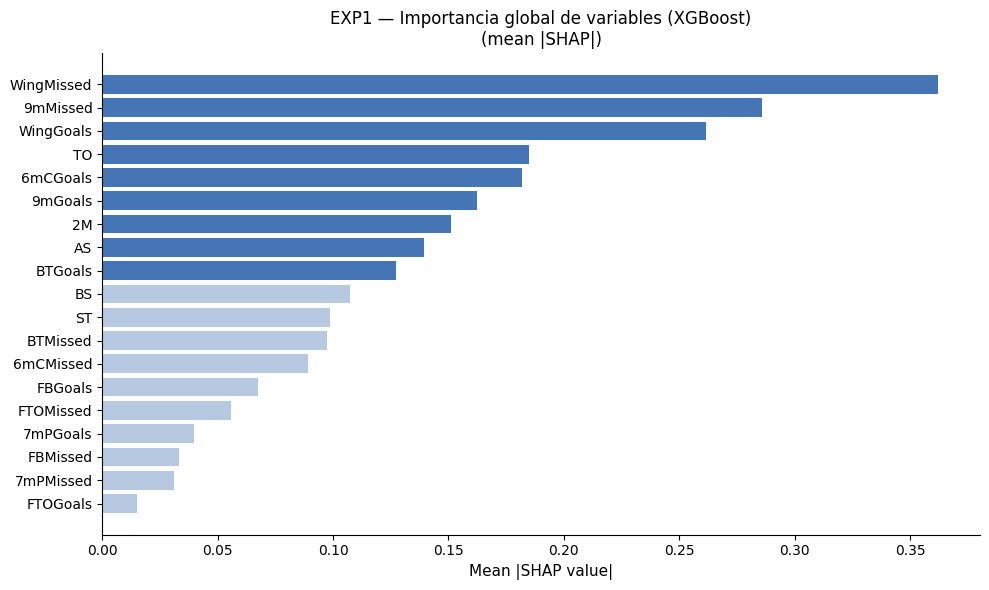


Top 10 variables más importantes (EXP1):


,mean_abs_shap
WingMissed,0.3622
9mMissed,0.2857
WingGoals,0.2617
TO,0.1848
6mCGoals,0.1820
9mGoals,0.1624
2M,0.1513
AS,0.1392
BTGoals,0.1273
BS,0.1072


In [281]:
if not SOLO_EXP2:
    # Elegir el mejor modelo por test accuracy
    accs1 = {name: accuracy_score(y1_test, p) for name, p in models_exp1}
    best_name1 = max(accs1, key=accs1.get)
    best_model1_map = {
        'Random Forest': rf1,
        'XGBoost':       xgb1,
    }
    print(f'Mejor modelo EXP1: {best_name1}  ({accs1[best_name1]:.4f})')
    
    # SHAP solo disponible directamente para modelos de árbol
    shap_model1_name = best_name1 if best_name1 in best_model1_map else 'XGBoost'
    shap_model1 = best_model1_map[shap_model1_name]
    
    X1_all_sc = scaler1.transform(X1)
    explainer1 = shap.TreeExplainer(shap_model1)
    shap_vals1 = explainer1.shap_values(X1_all_sc)
    
    # Importancia global
    if isinstance(shap_vals1, list):
        global_shap1 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals1], axis=0)
    else:
        global_shap1 = np.abs(shap_vals1).mean(axis=(0, 2)) if shap_vals1.ndim == 3 else np.abs(shap_vals1).mean(axis=0)
    
    shap_imp1 = pd.Series(global_shap1, index=FEATURE_COLS).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bar = ['#3266ad' if v > shap_imp1.median() else '#b0c4de' for v in shap_imp1.values]
    ax.barh(shap_imp1.index[::-1], shap_imp1.values[::-1], color=colors_bar[::-1], alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'EXP1 — Importancia global de variables ({shap_model1_name})\n(mean |SHAP|)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/shap_global_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\nTop 10 variables más importantes (EXP1):')
    display(shap_imp1.head(10).to_frame('mean_abs_shap').round(4))


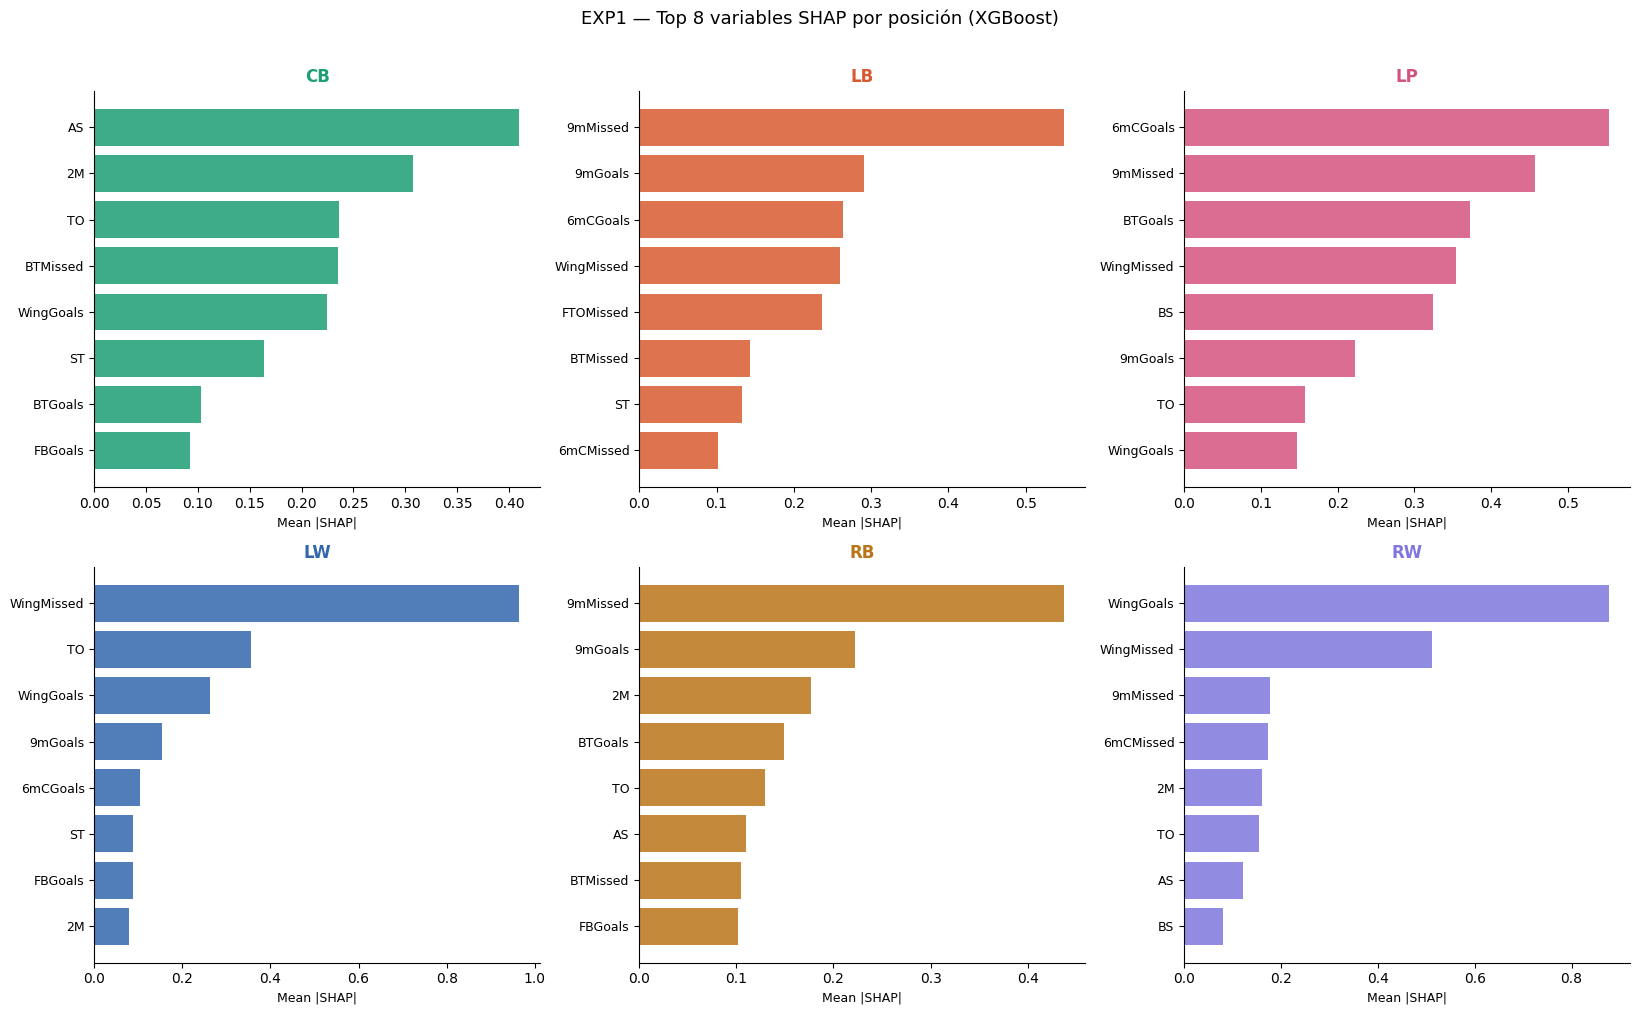

Guardada: position_output/exp1/shap_per_position.png


In [282]:
if not SOLO_EXP2:
    # SHAP por posición — EXP1
    if isinstance(shap_vals1, list):
        shap_list1 = shap_vals1
    elif shap_vals1.ndim == 3:
        shap_list1 = [shap_vals1[:, :, i] for i in range(shap_vals1.shape[2])]
    else:
        shap_list1 = [shap_vals1]
    
    classes1 = le1.classes_
    TOP_N = 8
    n_cls1 = len(classes1)
    n_cols1 = min(n_cls1, 3)
    n_rows1 = math.ceil(n_cls1 / n_cols1)
    
    fig, axes = plt.subplots(n_rows1, n_cols1, figsize=(n_cols1*5.5, n_rows1*5))
    axes = np.array(axes).flatten()
    
    for idx, cls in enumerate(classes1):
        sv = shap_list1[idx]
        mean_abs = np.abs(sv).mean(axis=0)
        importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
        top_vars = importance.head(TOP_N)
        color = POS_COLORS.get(cls, '#888')
        ax = axes[idx]
        ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.set_title(f'{cls}', fontsize=12, fontweight='bold', color=color)
        ax.spines[['top', 'right']].set_visible(False)
    
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f'EXP1 — Top {TOP_N} variables SHAP por posición ({shap_model1_name})',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/shap_per_position.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {OUT_ROOT}/exp1/shap_per_position.png')


---

# ══════════════════════════════════════════
# EXPERIMENTO 2 — Posiciones agrupadas 
# LW+RW → Wing | LB+RB → Lateral | CB → Central | LP → Pivote
# (4 clases)
# ══════════════════════════════════════════

In [283]:
# ── Mapeo de posiciones equivalentes ────────────────────────
POS_MAP = {
    'LW': 'Wing',    'RW': 'Wing',
    'LB': 'Lateral', 'RB': 'Lateral',
    'CB': 'Central',
    'LP': 'Pivote',
}

df_exp2 = df_full[df_full[TARGET_COL] != 'GK'].copy()
df_exp2['Grupo'] = df_exp2[TARGET_COL].map(POS_MAP)

print('[EXP 2] Distribución de grupos:')
print(df_exp2['Grupo'].value_counts())

X2 = df_exp2[FEATURE_COLS].values
y2_raw = df_exp2['Grupo'].values

le2 = LabelEncoder()
y2 = le2.fit_transform(y2_raw)
print('\nClases EXP 2:', le2.classes_)

[EXP 2] Distribución de grupos:
Grupo
Lateral    134
Wing        95
Pivote      64
Central     58
Name: count, dtype: int64

Clases EXP 2: ['Central' 'Lateral' 'Pivote' 'Wing']


### 2.1 Split 80/20 estratificado + Estandarización z-score

In [284]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

scaler2 = StandardScaler()              # z-score
X2_train_sc = scaler2.fit_transform(X2_train)   # fit SOLO en train
X2_test_sc  = scaler2.transform(X2_test)        # transform en test

print(f'Train: {X2_train_sc.shape[0]}  |  Test: {X2_test_sc.shape[0]}')

Train: 280  |  Test: 71


### 2.2 Random Forest + GridSearchCV

In [285]:
gs_rf2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf2.fit(X2_train_sc, y2_train)
rf2 = gs_rf2.best_estimator_

print(f'[EXP2 RF] Mejores hiperparámetros: {gs_rf2.best_params_}')
y2_pred_rf = rf2.predict(X2_test_sc)
train_acc_rf2 = accuracy_score(y2_train, rf2.predict(X2_train_sc))

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', rf2)
    ])

cv_rf2 = cross_val_score(rf2, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 RF] Train accuracy: {train_acc_rf2:.4f}')
print(f'[EXP2 RF] Test accuracy:  {accuracy_score(y2_test, y2_pred_rf):.4f}')
print(f'[EXP2 RF] Diferencia Train-Test: {train_acc_rf2 - accuracy_score(y2_test, y2_pred_rf):.4f}')
print(classification_report(y2_test, y2_pred_rf, target_names=le2.classes_))

[EXP2 RF] Mejores hiperparámetros: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}
[EXP2 RF] Train accuracy: 0.9107
[EXP2 RF] Test accuracy:  0.7606
[EXP2 RF] Diferencia Train-Test: 0.1502
              precision    recall  f1-score   support

     Central       0.38      0.25      0.30        12
     Lateral       0.71      0.74      0.73        27
      Pivote       0.76      1.00      0.87        13
        Wing       1.00      0.95      0.97        19

    accuracy                           0.76        71
   macro avg       0.71      0.73      0.72        71
weighted avg       0.74      0.76      0.75        71



### 2.3 XGBoost + GridSearchCV

In [286]:
gs_xgb2 = GridSearchCV(
    xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_grid_xgb, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_xgb2.fit(X2_train_sc, y2_train)
xgb2 = gs_xgb2.best_estimator_

print(f'[EXP2 XGB] Mejores hiperparámetros: {gs_xgb2.best_params_}')
y2_pred_xgb = xgb2.predict(X2_test_sc)
train_acc_xgb2 = accuracy_score(y2_train, xgb2.predict(X2_train_sc))

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb2)
    ])


cv_xgb2 = cross_val_score(pipeline_xgb, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 XGB] Train accuracy: {train_acc_xgb2:.4f}')
print(f'[EXP2 XGB] Test accuracy:  {accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(f'[EXP2 XGB] Diferencia Train-Test: {train_acc_xgb2 - accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(classification_report(y2_test, y2_pred_xgb, target_names=le2.classes_))

[EXP2 XGB] Mejores hiperparámetros: {'colsample_bytree': 0.9, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 15, 'reg_alpha': 0.5}
[EXP2 XGB] Train accuracy: 0.9250
[EXP2 XGB] Test accuracy:  0.7887
[EXP2 XGB] Diferencia Train-Test: 0.1363
              precision    recall  f1-score   support

     Central       0.40      0.33      0.36        12
     Lateral       0.72      0.78      0.75        27
      Pivote       0.93      1.00      0.96        13
        Wing       1.00      0.95      0.97        19

    accuracy                           0.79        71
   macro avg       0.76      0.76      0.76        71
weighted avg       0.78      0.79      0.78        71



### 2.4 SVM + GridSearchCV

In [287]:
gs_svm2 = GridSearchCV(
    SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    param_grid_svm, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_svm2.fit(X2_train_sc, y2_train)
svm2 = gs_svm2.best_estimator_

print(f'[EXP2 SVM] Mejores hiperparámetros: {gs_svm2.best_params_}')
y2_pred_svm = svm2.predict(X2_test_sc)
train_acc_svm2 = accuracy_score(y2_train, svm2.predict(X2_train_sc))

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', svm2)
    ])

cv_svm2 = cross_val_score(pipeline_svm, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 SVM] Train accuracy: {train_acc_svm2:.4f}')
print(f'[EXP2 SVM] Test accuracy:  {accuracy_score(y2_test, y2_pred_svm):.4f}')
print(f'[EXP2 SVM] Diferencia Train-Test: {train_acc_svm2 - accuracy_score(y2_test, y2_pred_svm):.4f}')
print(classification_report(y2_test, y2_pred_svm, target_names=le2.classes_))

[EXP2 SVM] Mejores hiperparámetros: {'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
[EXP2 SVM] Train accuracy: 0.7714
[EXP2 SVM] Test accuracy:  0.7183
[EXP2 SVM] Diferencia Train-Test: 0.0531
              precision    recall  f1-score   support

     Central       0.33      0.42      0.37        12
     Lateral       0.84      0.59      0.70        27
      Pivote       0.65      1.00      0.79        13
        Wing       1.00      0.89      0.94        19

    accuracy                           0.72        71
   macro avg       0.71      0.73      0.70        71
weighted avg       0.76      0.72      0.72        71



### 2.5 Red Neuronal (MLP) + GridSearchCV

In [288]:
gs_mlp2 = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    param_grid_mlp, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_mlp2.fit(X2_train_sc, y2_train)
mlp2 = gs_mlp2.best_estimator_

print(f'[EXP2 MLP] Mejores hiperparámetros: {gs_mlp2.best_params_}')
y2_pred_mlp = mlp2.predict(X2_test_sc)
train_acc_mlp2 = accuracy_score(y2_train, mlp2.predict(X2_train_sc))

pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', mlp2)
    ])

cv_mlp2 = cross_val_score(pipeline_mlp, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 MLP] Train accuracy: {train_acc_mlp2:.4f}')
print(f'[EXP2 MLP] Test accuracy:  {accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(f'[EXP2 MLP] Diferencia Train-Test: {train_acc_mlp2 - accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(classification_report(y2_test, y2_pred_mlp, target_names=le2.classes_))

[EXP2 MLP] Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.0005, 'hidden_layer_sizes': (512, 256, 128), 'learning_rate': 'adaptive', 'learning_rate_init': 0.005}
[EXP2 MLP] Train accuracy: 0.8464
[EXP2 MLP] Test accuracy:  0.8169
[EXP2 MLP] Diferencia Train-Test: 0.0295
              precision    recall  f1-score   support

     Central       0.67      0.50      0.57        12
     Lateral       0.79      0.81      0.80        27
      Pivote       0.76      1.00      0.87        13
        Wing       1.00      0.89      0.94        19

    accuracy                           0.82        71
   macro avg       0.80      0.80      0.80        71
weighted avg       0.82      0.82      0.81        71



### 2.6 Matrices de confusión — EXP 2 (imágenes)

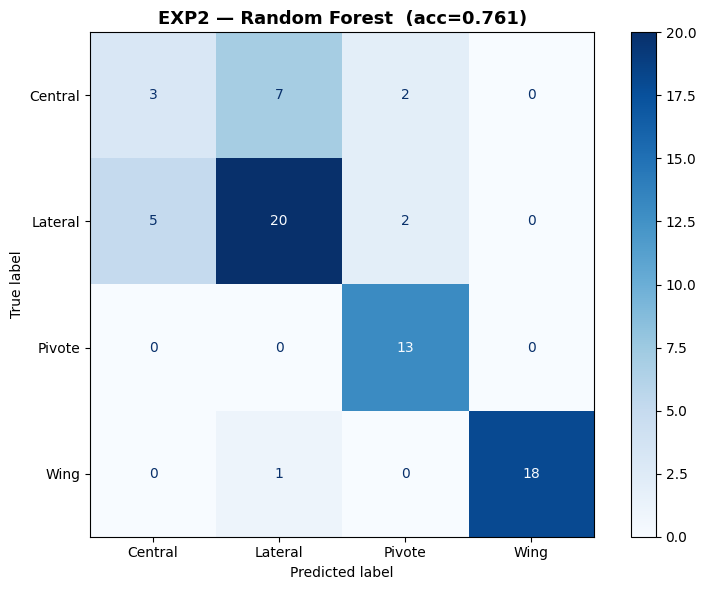

Guardada: position_output/exp2/cm_random_forest.png


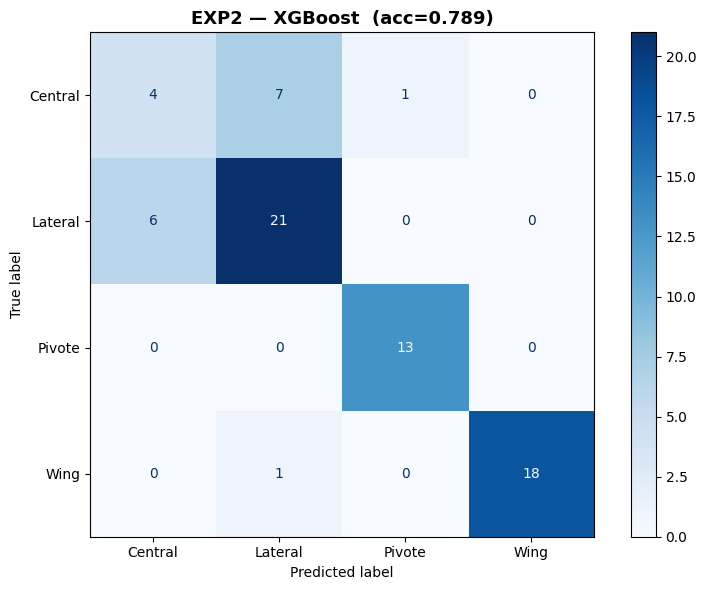

Guardada: position_output/exp2/cm_xgboost.png


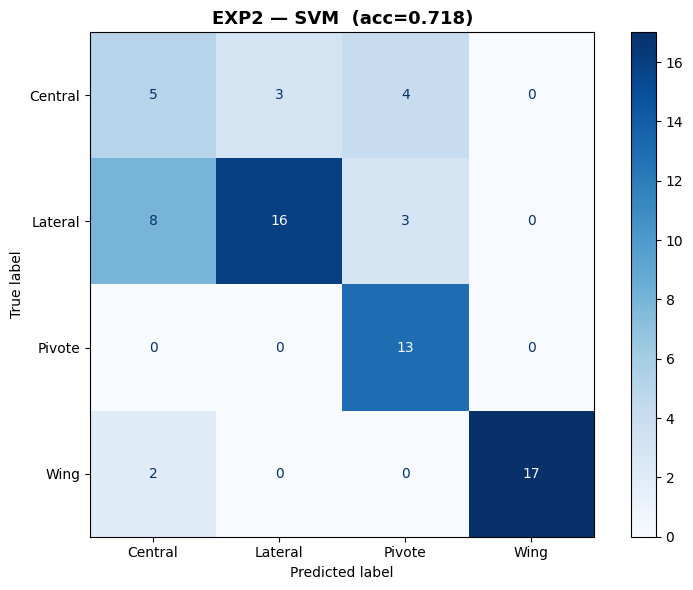

Guardada: position_output/exp2/cm_svm.png


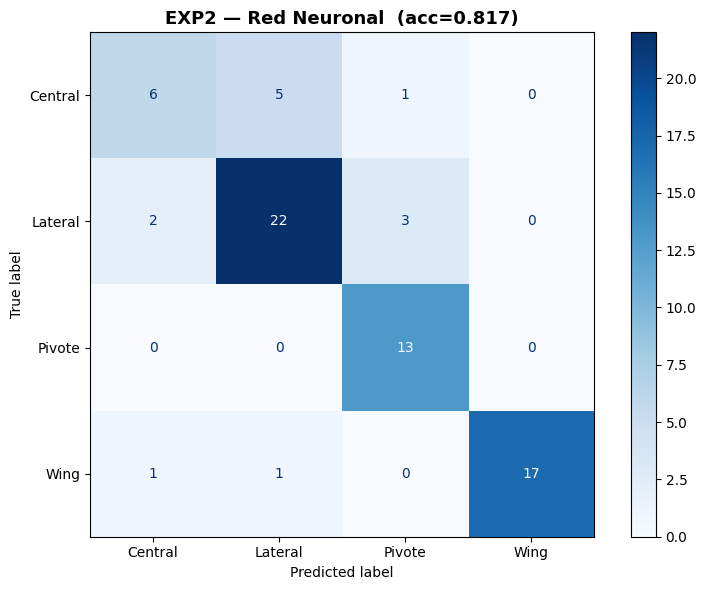

Guardada: position_output/exp2/cm_red_neuronal.png


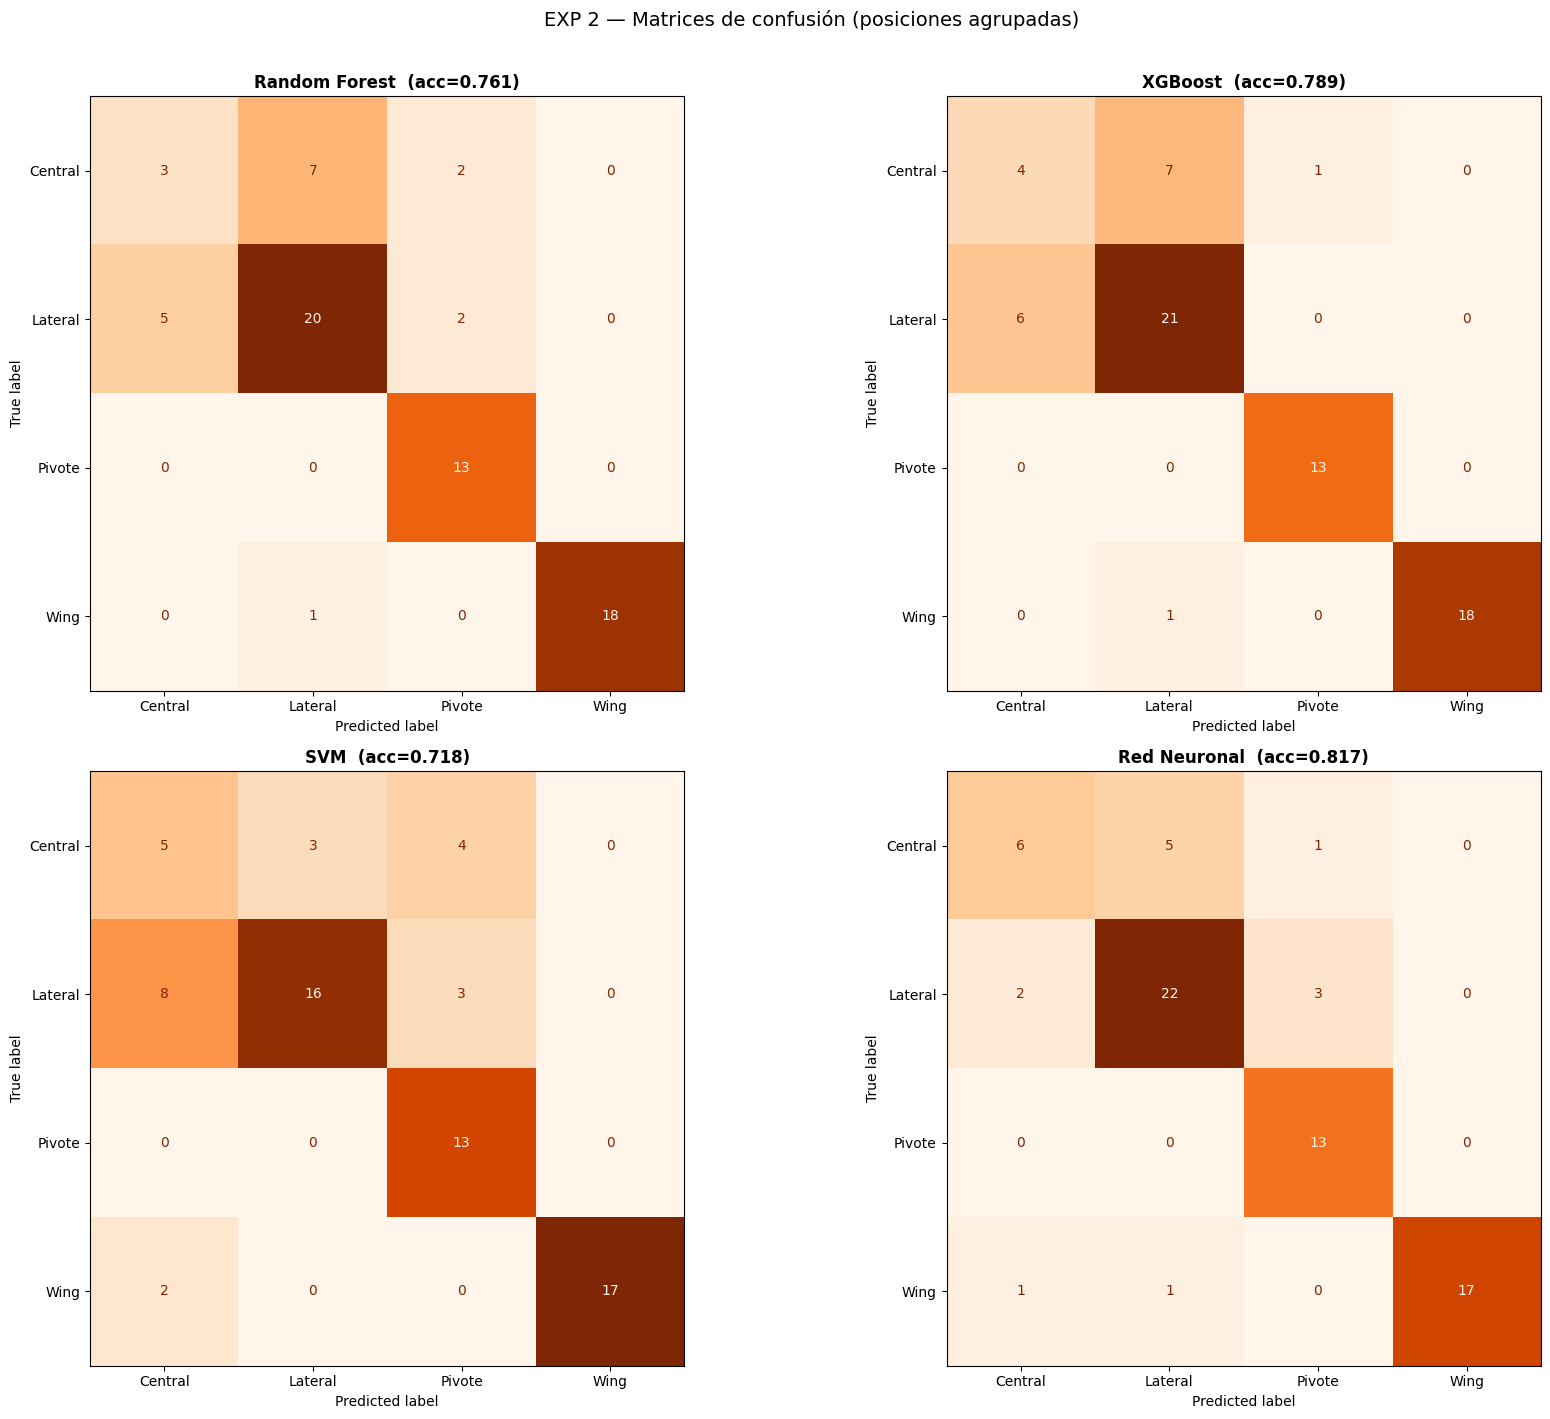

Guardada figura combinada: position_output/exp2/confusion_matrices_all.png


In [289]:
models_exp2 = [
    ('Random Forest', y2_pred_rf),
    ('XGBoost',       y2_pred_xgb),
    ('SVM',           y2_pred_svm),
    ('Red Neuronal',  y2_pred_mlp),
]

for name, preds in models_exp2:
    path = f"{OUT_ROOT}/exp2/cm_{name.replace(' ','_').lower()}.png"
    save_confusion_matrix(y2_test, preds, le2, f'EXP2 — {name}', path)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_exp2):
    cm = confusion_matrix(y2_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le2.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    acc = accuracy_score(y2_test, preds)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
plt.suptitle('EXP 2 — Matrices de confusión (posiciones agrupadas)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Guardada figura combinada: {OUT_ROOT}/exp2/confusion_matrices_all.png")

### 2.7 Tabla de métricas — EXP 2

In [290]:
train_accs2 = [train_acc_rf2, train_acc_xgb2, train_acc_svm2, train_acc_mlp2]
cvs2 = [
    (cv_rf2.mean(),  cv_rf2.std()),
    (cv_xgb2.mean(), cv_xgb2.std()),
    (cv_svm2.mean(), cv_svm2.std()),
    (cv_mlp2.mean(), cv_mlp2.std()),
]

rows_exp2 = []
for (name, preds), (cv_m, cv_s), tr_acc in zip(models_exp2, cvs2, train_accs2):
    rows_exp2.append(metrics_table(y2_test, preds, le2, name, cv_m, cv_s, tr_acc))

df_metrics_exp2 = pd.DataFrame(rows_exp2).set_index('Modelo')
col_order2 = ['Train Accuracy', 'CV Accuracy (mean)', 'CV Accuracy (std)',
              'Accuracy', 'Diferencia (Train-CV)', 'F1 (weighted)', 'F1 (macro)',
              'Precision (weighted)', 'Recall (weighted)']
df_metrics_exp2 = df_metrics_exp2[[c for c in col_order2 if c in df_metrics_exp2.columns]]
print('=== EXP 2 — Métricas globales ===')
display(df_metrics_exp2.style.background_gradient(subset=['Diferencia (Train-CV)'], cmap='RdYlGn_r'))
df_metrics_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_global.csv')

rows_class_exp2 = []
for name, preds in models_exp2:
    rows_class_exp2.extend(per_class_table(y2_test, preds, le2, name))
df_class_exp2 = pd.DataFrame(rows_class_exp2)
print('\n=== EXP 2 — Métricas por clase ===')
display(df_class_exp2)
df_class_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_per_class.csv', index=False)


=== EXP 2 — Métricas globales ===


,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Accuracy,Diferencia (Train-CV),F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,,,,,
Random Forest,0.910700,0.764300,0.051000,0.760600,0.146400,0.746300,0.716700,0.742600,0.760600
XGBoost,0.925000,0.767900,0.039100,0.788700,0.157100,0.783400,0.762400,0.780600,0.788700
SVM,0.771400,0.700000,0.048400,0.718300,0.071400,0.724100,0.699600,0.763200,0.718300
Red Neuronal,0.846400,0.725000,0.043200,0.816900,0.121400,0.812200,0.795600,0.819100,0.816900



=== EXP 2 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,Central,0.3750,0.2500,0.3000
1,Random Forest,Lateral,0.7143,0.7407,0.7273
2,Random Forest,Pivote,0.7647,1.0000,0.8667
3,Random Forest,Wing,1.0000,0.9474,0.9730
4,XGBoost,Central,0.4000,0.3333,0.3636
5,XGBoost,Lateral,0.7241,0.7778,0.7500
6,XGBoost,Pivote,0.9286,1.0000,0.9630
7,XGBoost,Wing,1.0000,0.9474,0.9730
8,SVM,Central,0.3333,0.4167,0.3704
9,SVM,Lateral,0.8421,0.5926,0.6957


### 2.9 Comprobación de sobreajuste — EXP 2

Mismo análisis que en EXP 1: comparación Train / CV / Test y curvas de aprendizaje para los 4 modelos con posiciones agrupadas.

=== EXP 2 — Comprobación de sobreajuste ===


,Train Accuracy,CV Accuracy (mean),CV Std (±),Test Accuracy,Diferencia Train-CV,Diferencia Train-Test
Modelo,,,,,,
Random Forest,0.910700,0.764300,0.051000,0.760600,0.146400,0.150200
XGBoost,0.925000,0.767900,0.039100,0.788700,0.157100,0.136300
SVM,0.771400,0.700000,0.048400,0.718300,0.071400,0.053100
Red Neuronal,0.846400,0.725000,0.043200,0.816900,0.121400,0.029500


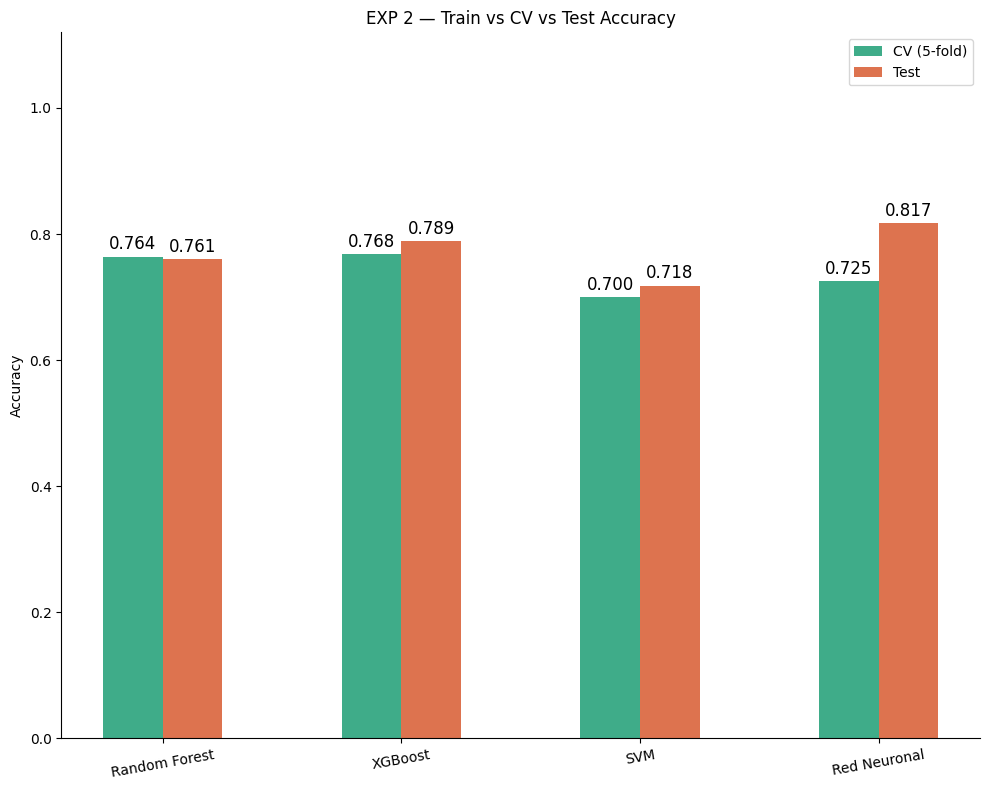

Guardada: position_output/exp2/overfit_train_cv_test.png


In [291]:
# ── Tabla resumen Train / CV / Test — EXP2 ──────────────────
models_exp2_dict = {
    'Random Forest': (rf2,  train_acc_rf2,  cv_rf2,  y2_pred_rf),
    'XGBoost':       (xgb2, train_acc_xgb2, cv_xgb2, y2_pred_xgb),
    'SVM':           (svm2, train_acc_svm2, cv_svm2, y2_pred_svm),
    'Red Neuronal':  (mlp2, train_acc_mlp2, cv_mlp2, y2_pred_mlp),
}

overfit_rows2 = []
for mname, (model, tr_acc, cv_scores, preds) in models_exp2_dict.items():
    test_acc = accuracy_score(y2_test, preds)
    overfit_rows2.append({
        'Modelo':            mname,
        'Train Accuracy':    round(tr_acc, 4),
        'CV Accuracy (mean)':round(cv_scores.mean(), 4),
        'CV Std (±)':        round(cv_scores.std(), 4),
        'Test Accuracy':     round(test_acc, 4),
        'Diferencia Train-CV':      round(tr_acc - cv_scores.mean(), 4),
        'Diferencia Train-Test':    round(tr_acc - test_acc, 4),
    })

df_overfit2 = pd.DataFrame(overfit_rows2).set_index('Modelo')
print('=== EXP 2 — Comprobación de sobreajuste ===')
display(df_overfit2.style.background_gradient(subset=['Diferencia Train-CV', 'Diferencia Train-Test'],
                                               cmap='RdYlGn_r'))
df_overfit2.to_csv(f'{OUT_ROOT}/exp2/overfit_diagnosis.csv')

width  = 0.25

# ── Gráfico: Train vs CV vs Test Accuracy — EXP2 ────────────
fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(overfit_rows2))
names2   = [r['Modelo'] for r in overfit_rows2]
tr_vals2 = [r['Train Accuracy']     for r in overfit_rows2]
cv_vals2 = [r['CV Accuracy (mean)'] for r in overfit_rows2]
te_vals2 = [r['Test Accuracy']      for r in overfit_rows2]

b2 = ax.bar(x - width/2, cv_vals2, width, label='CV (5-fold)', color='#1d9e75', alpha=0.85)
b3 = ax.bar(x + width/2, te_vals2, width, label='Test',        color='#d85a30', alpha=0.85)

for bars in [b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(names2, rotation=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy')
ax.set_title('EXP 2 — Train vs CV vs Test Accuracy', fontsize=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/overfit_train_cv_test.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/overfit_train_cv_test.png')


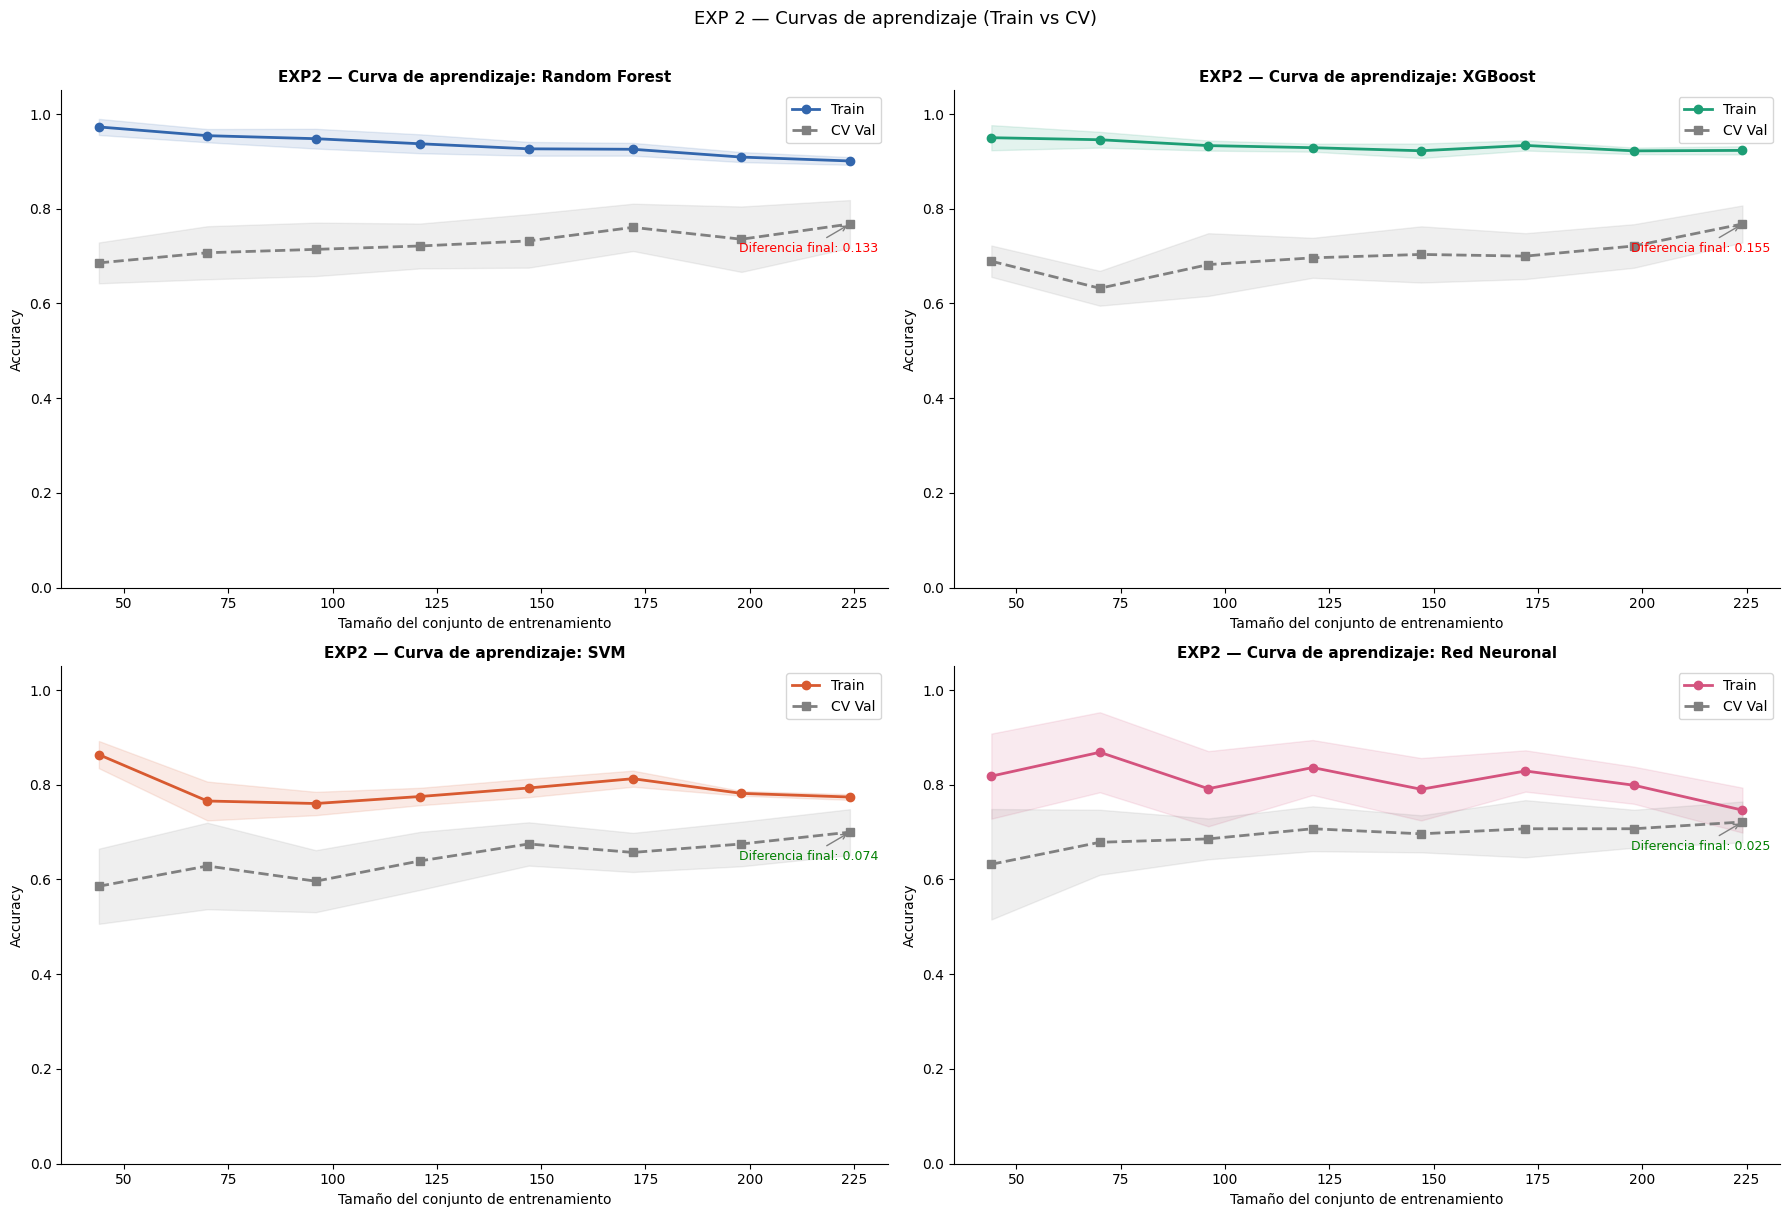

Guardada: position_output/exp2/learning_curves.png


In [292]:
# ── Curvas de aprendizaje — EXP 2 ───────────────────────────
lc_models2 = [
    ('Random Forest', rf2,  '#3266ad'),
    ('XGBoost',       xgb2, '#1d9e75'),
    ('SVM',           svm2, '#d85a30'),
    ('Red Neuronal',  mlp2, '#d4537e'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (mname, model, color) in zip(axes, lc_models2):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X2_train_sc, y2_train,
        cv=cv5, scoring='accuracy',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )
    tr_mean  = train_scores.mean(axis=1)
    tr_std   = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean,  'o-', color=color,   label='Train',  linewidth=2)
    ax.plot(train_sizes, val_mean, 's--', color='gray', label='CV Val', linewidth=2)
    ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='gray')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'EXP2 — Curva de aprendizaje: {mname}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    Diferencia = tr_mean[-1] - val_mean[-1]
    ax.annotate(f'Diferencia final: {Diferencia:.3f}',
                xy=(train_sizes[-1], val_mean[-1]),
                xytext=(-80, -20), textcoords='offset points',
                fontsize=9, color='red' if Diferencia > 0.10 else 'green',
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle('EXP 2 — Curvas de aprendizaje (Train vs CV)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/learning_curves.png')


### 2.8 Análisis SHAP — EXP 2 (mejor modelo)

Mejor modelo EXP2: Red Neuronal  (0.8169)


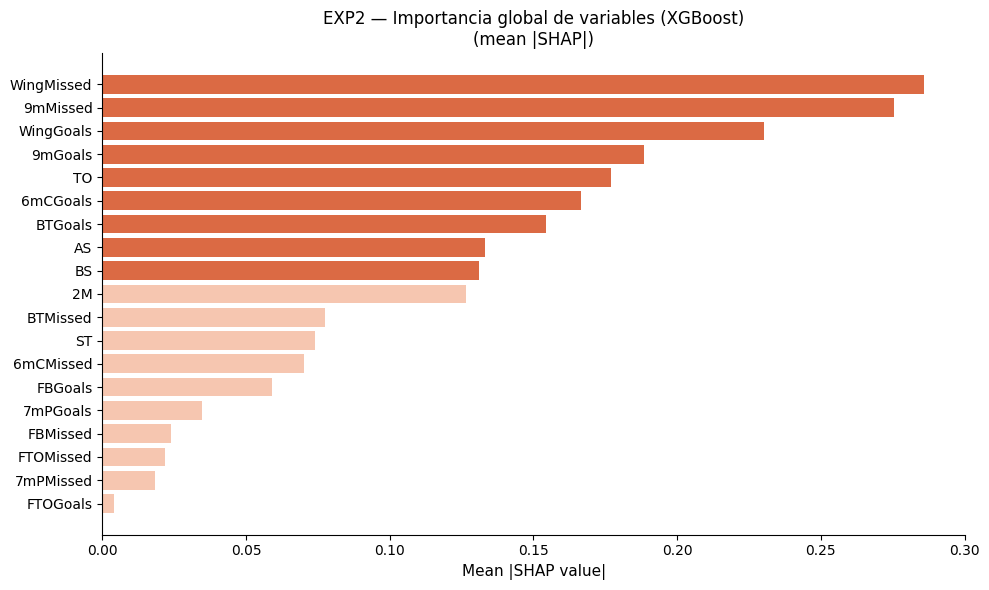


Top 10 variables más importantes (EXP2):


,mean_abs_shap
WingMissed,0.2859
9mMissed,0.2756
WingGoals,0.2301
9mGoals,0.1883
TO,0.1768
6mCGoals,0.1666
BTGoals,0.1544
AS,0.1331
BS,0.1312
2M,0.1266


In [293]:
accs2 = {name: accuracy_score(y2_test, p) for name, p in models_exp2}
best_name2 = max(accs2, key=accs2.get)
best_model2_map = {'Random Forest': rf2, 'XGBoost': xgb2}
shap_model2_name = best_name2 if best_name2 in best_model2_map else 'XGBoost'
shap_model2 = best_model2_map[shap_model2_name]
print(f'Mejor modelo EXP2: {best_name2}  ({accs2[best_name2]:.4f})')

X2_all_sc = scaler2.transform(X2)
explainer2 = shap.TreeExplainer(shap_model2)
shap_vals2 = explainer2.shap_values(X2_all_sc)

if isinstance(shap_vals2, list):
    global_shap2 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals2], axis=0)
else:
    global_shap2 = np.abs(shap_vals2).mean(axis=(0, 2)) if shap_vals2.ndim == 3 else np.abs(shap_vals2).mean(axis=0)

shap_imp2 = pd.Series(global_shap2, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar2 = ['#d85a30' if v > shap_imp2.median() else '#f5c0a8' for v in shap_imp2.values]
ax.barh(shap_imp2.index[::-1], shap_imp2.values[::-1], color=colors_bar2[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'EXP2 — Importancia global de variables ({shap_model2_name})\n(mean |SHAP|)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10 variables más importantes (EXP2):')
display(shap_imp2.head(10).to_frame('mean_abs_shap').round(4))

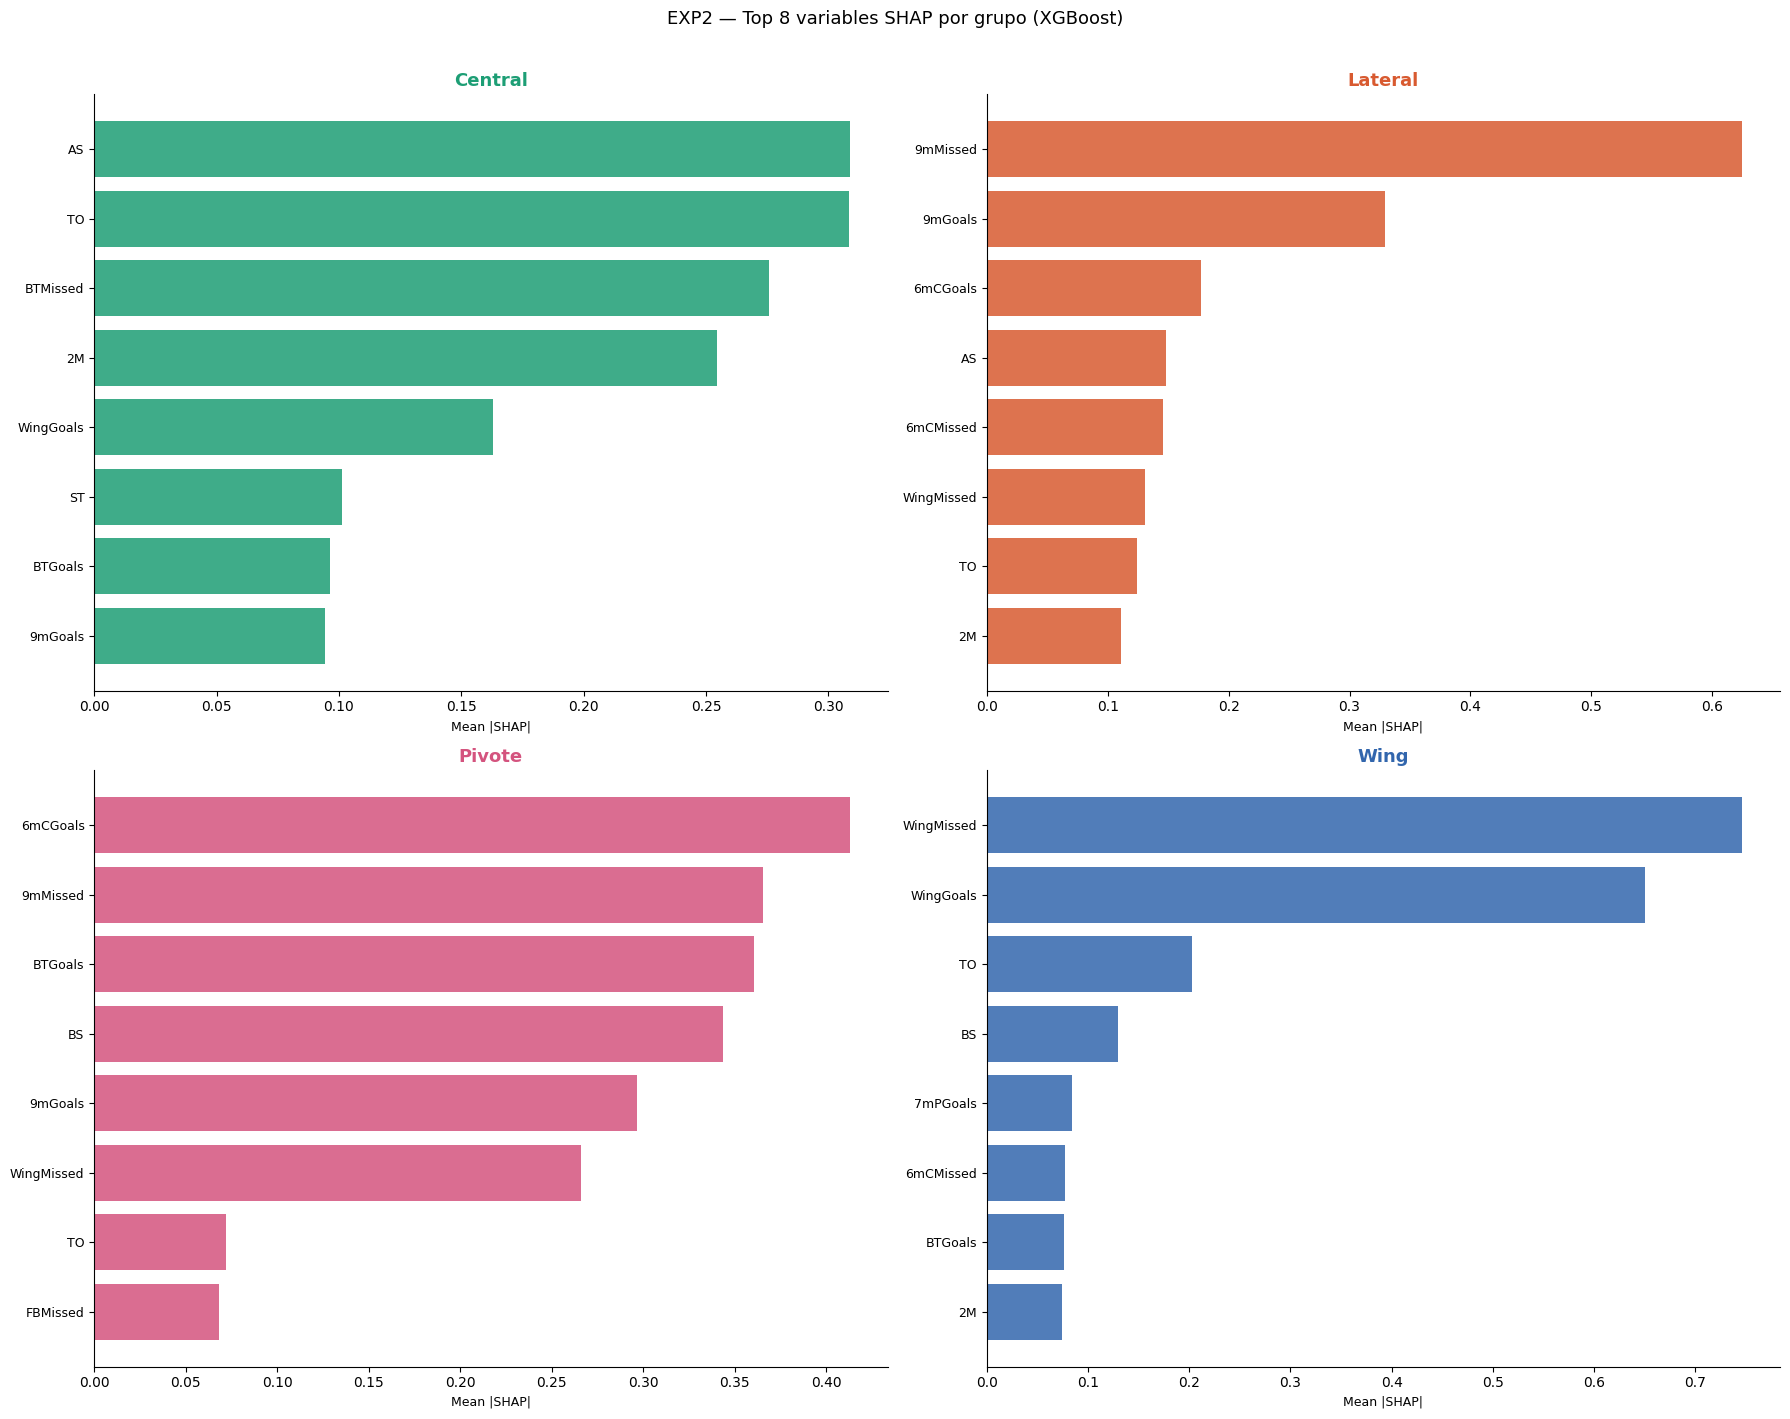

Guardada: position_output/exp2/shap_per_group.png


In [294]:
# SHAP por grupo — EXP2
if isinstance(shap_vals2, list):
    shap_list2 = shap_vals2
elif shap_vals2.ndim == 3:
    shap_list2 = [shap_vals2[:, :, i] for i in range(shap_vals2.shape[2])]
else:
    shap_list2 = [shap_vals2]

TOP_N = 8
classes2 = le2.classes_
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, cls in enumerate(classes2):
    sv = shap_list2[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    top_vars = importance.head(TOP_N)
    color = POS_COLORS.get(cls, '#888')
    ax = axes[idx]
    ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}', fontsize=13, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'EXP2 — Top {TOP_N} variables SHAP por grupo ({shap_model2_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_per_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/shap_per_group.png')

---

# ══════════════════════════════════════════
# COMPARATIVA ENTRE EXPERIMENTOS
# ══════════════════════════════════════════

  RESUMEN DE EXPERIMENTOS

--- EXP 1 (6 clases) ---


,Accuracy,F1 (weighted),F1 (macro),CV Accuracy (mean)
Modelo,,,,
Random Forest,0.6197,0.5991,0.5812,0.5250
XGBoost,0.6479,0.6288,0.6015,0.5429
SVM,0.4507,0.4495,0.4522,0.5429
Red Neuronal,0.4930,0.4144,0.3845,0.4500



--- EXP 2 (4 clases) ---


,Accuracy,F1 (weighted),F1 (macro),CV Accuracy (mean)
Modelo,,,,
Random Forest,0.7606,0.7463,0.7167,0.7643
XGBoost,0.7887,0.7834,0.7624,0.7679
SVM,0.7183,0.7241,0.6996,0.7000
Red Neuronal,0.8169,0.8122,0.7956,0.7250


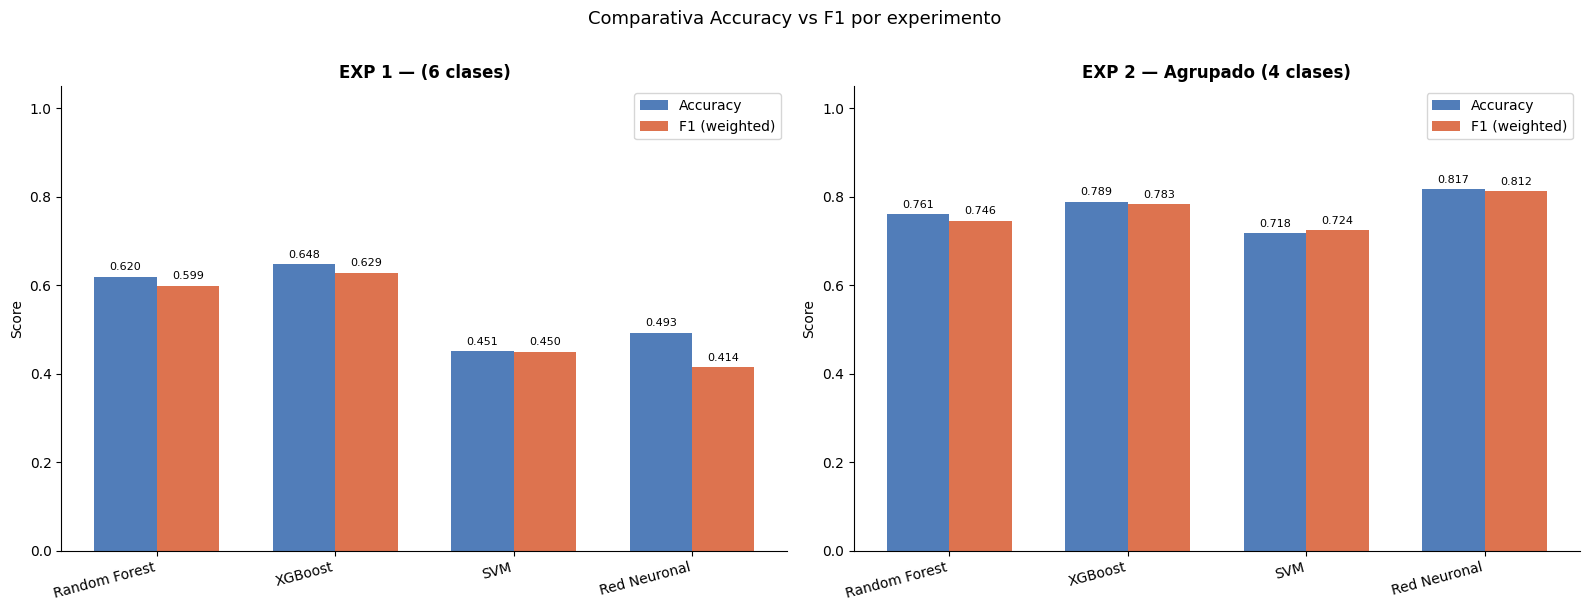

Guardada: position_output/comparativa_experimentos.png


In [295]:
print('=' * 55)
print('  RESUMEN DE EXPERIMENTOS')
print('=' * 55)
if not SOLO_EXP2:
    print('\n--- EXP 1 (6 clases) ---')
    display(df_metrics_exp1[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'CV Accuracy (mean)']])

print('\n--- EXP 2 (4 clases) ---')
display(df_metrics_exp2[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'CV Accuracy (mean)']])

# Gráfico comparativo
pairs_met = []
if not SOLO_EXP2:
    pairs_met.append((df_metrics_exp1, 'EXP 1 — (6 clases)'))
pairs_met.append((df_metrics_exp2, 'EXP 2 — Agrupado (4 clases)'))
fig, axes = plt.subplots(1, len(pairs_met), figsize=(8*len(pairs_met), 6), sharey=False)
if len(pairs_met) == 1: axes = [axes]
for ax, (df_met, title) in zip(axes, pairs_met):
    x = range(len(df_met))
    width = 0.35
    bars1 = ax.bar([i - width/2 for i in x], df_met['Accuracy'],
                   width, label='Accuracy', color='#3266ad', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], df_met['F1 (weighted)'],
                   width, label='F1 (weighted)', color='#d85a30', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_met.index, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa Accuracy vs F1 por experimento', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/comparativa_experimentos.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/comparativa_experimentos.png')

---

# ══════════════════════════════════════════
# MODELO FINAL ROBUSTO
# Entrenar con el 100% de los datos (train+test)
# una vez validados los experimentos
# ══════════════════════════════════════════

In [296]:
if not SOLO_EXP2:
    # ── EXP 1 — Modelo final sobre todos los datos () ─────
    print('=== MODELO FINAL — EXP 1 () ===')
    
    X1_all_full = df_exp1[FEATURE_COLS].values
    y1_all_full = le1.transform(df_exp1[TARGET_COL].values)
    
    scaler1_final = StandardScaler()
    X1_all_sc_final = scaler1_final.fit_transform(X1_all_full)
    
    # Usamos los mejores hiperparámetros encontrados en el experimento
    rf1_final = RandomForestClassifier(
        **gs_rf1.best_params_,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    rf1_final.fit(X1_all_sc_final, y1_all_full)
    print(f'RF EXP1 final entrenado con {len(y1_all_full)} instancias. Clases: {le1.classes_}')

# ── EXP 2 — Modelo final sobre todos los datos (grupos) ─────
print('\n=== MODELO FINAL — EXP 2 (agrupado) ===')

X2_all_full = df_exp2[FEATURE_COLS].values
y2_all_full = le2.transform(df_exp2['Grupo'].values)

scaler2_final = StandardScaler()
X2_all_sc_final = scaler2_final.fit_transform(X2_all_full)

rf2_final = RandomForestClassifier(
    **gs_rf2.best_params_,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf2_final.fit(X2_all_sc_final, y2_all_full)
print(f'RF EXP2 final entrenado con {len(y2_all_full)} instancias. Clases: {le2.classes_}')

=== MODELO FINAL — EXP 1 () ===
RF EXP1 final entrenado con 351 instancias. Clases: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']

=== MODELO FINAL — EXP 2 (agrupado) ===
RF EXP2 final entrenado con 351 instancias. Clases: ['Central' 'Lateral' 'Pivote' 'Wing']


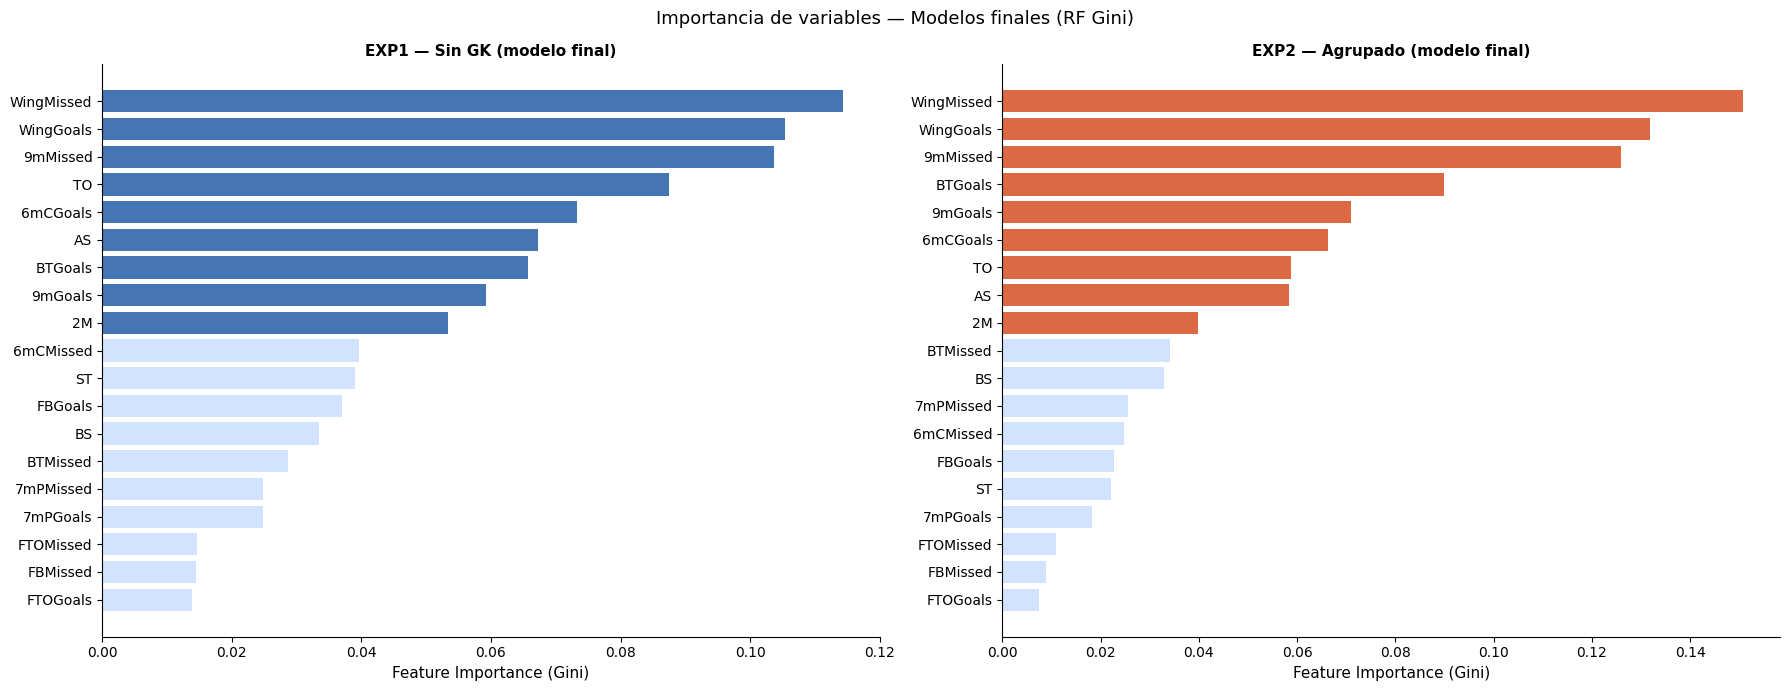

 Guardada: position_output/final/feature_importance_final.png
Todos los artefactos en: position_output/


In [297]:
# ── Importancia de variables del modelo final (RF, Gini) ────
pairs = []
if not SOLO_EXP2:
    pairs.append((rf1_final, scaler1_final, 'EXP1 — Sin GK (modelo final)', '#3266ad'))
pairs.append((rf2_final, scaler2_final, 'EXP2 — Agrupado (modelo final)', '#d85a30'))
fig, axes = plt.subplots(1, len(pairs), figsize=(9*len(pairs), 7))
if len(pairs) == 1: axes = [axes]
for ax, (rf_fin, scaler_fin, title_exp, color_bar) in zip(axes, pairs):
    imp = pd.Series(rf_fin.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    colors_imp = [color_bar if v > imp.median() else '#cce0ff' for v in imp.values]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors_imp[::-1], alpha=0.9)
    ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
    ax.set_title(title_exp, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Importancia de variables — Modelos finales (RF Gini)', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/final/feature_importance_final.png', dpi=130, bbox_inches='tight')
plt.show()
print(f' Guardada: {OUT_ROOT}/final/feature_importance_final.png')

print(f'Todos los artefactos en: {OUT_ROOT}/')

### SHAP — Modelos finales (train+test completo)

Análisis SHAP sobre los modelos finales entrenados con el 100% de los datos. Al haber visto más ejemplos, los valores de importancia son más estables y representativos que los obtenidos durante los experimentos.


=== SHAP EXP1 — (6 clases) ===


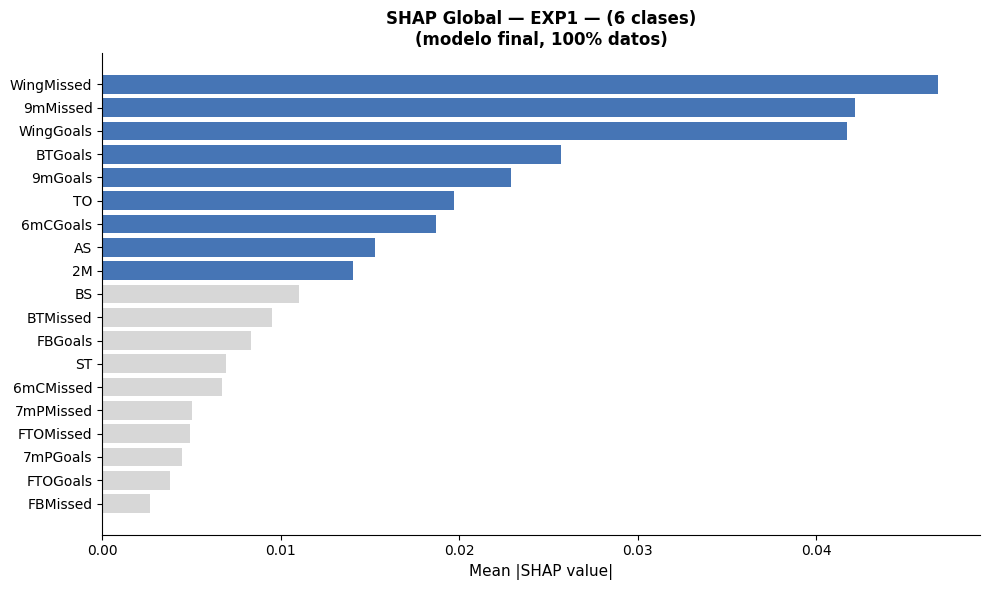

position_output/final/shap_exp1_final_global.png

Top 10 variables:


,mean_abs_shap
WingMissed,0.0468
9mMissed,0.0422
WingGoals,0.0417
BTGoals,0.0257
9mGoals,0.0229
TO,0.0197
6mCGoals,0.0187
AS,0.0153
2M,0.0140
BS,0.0110


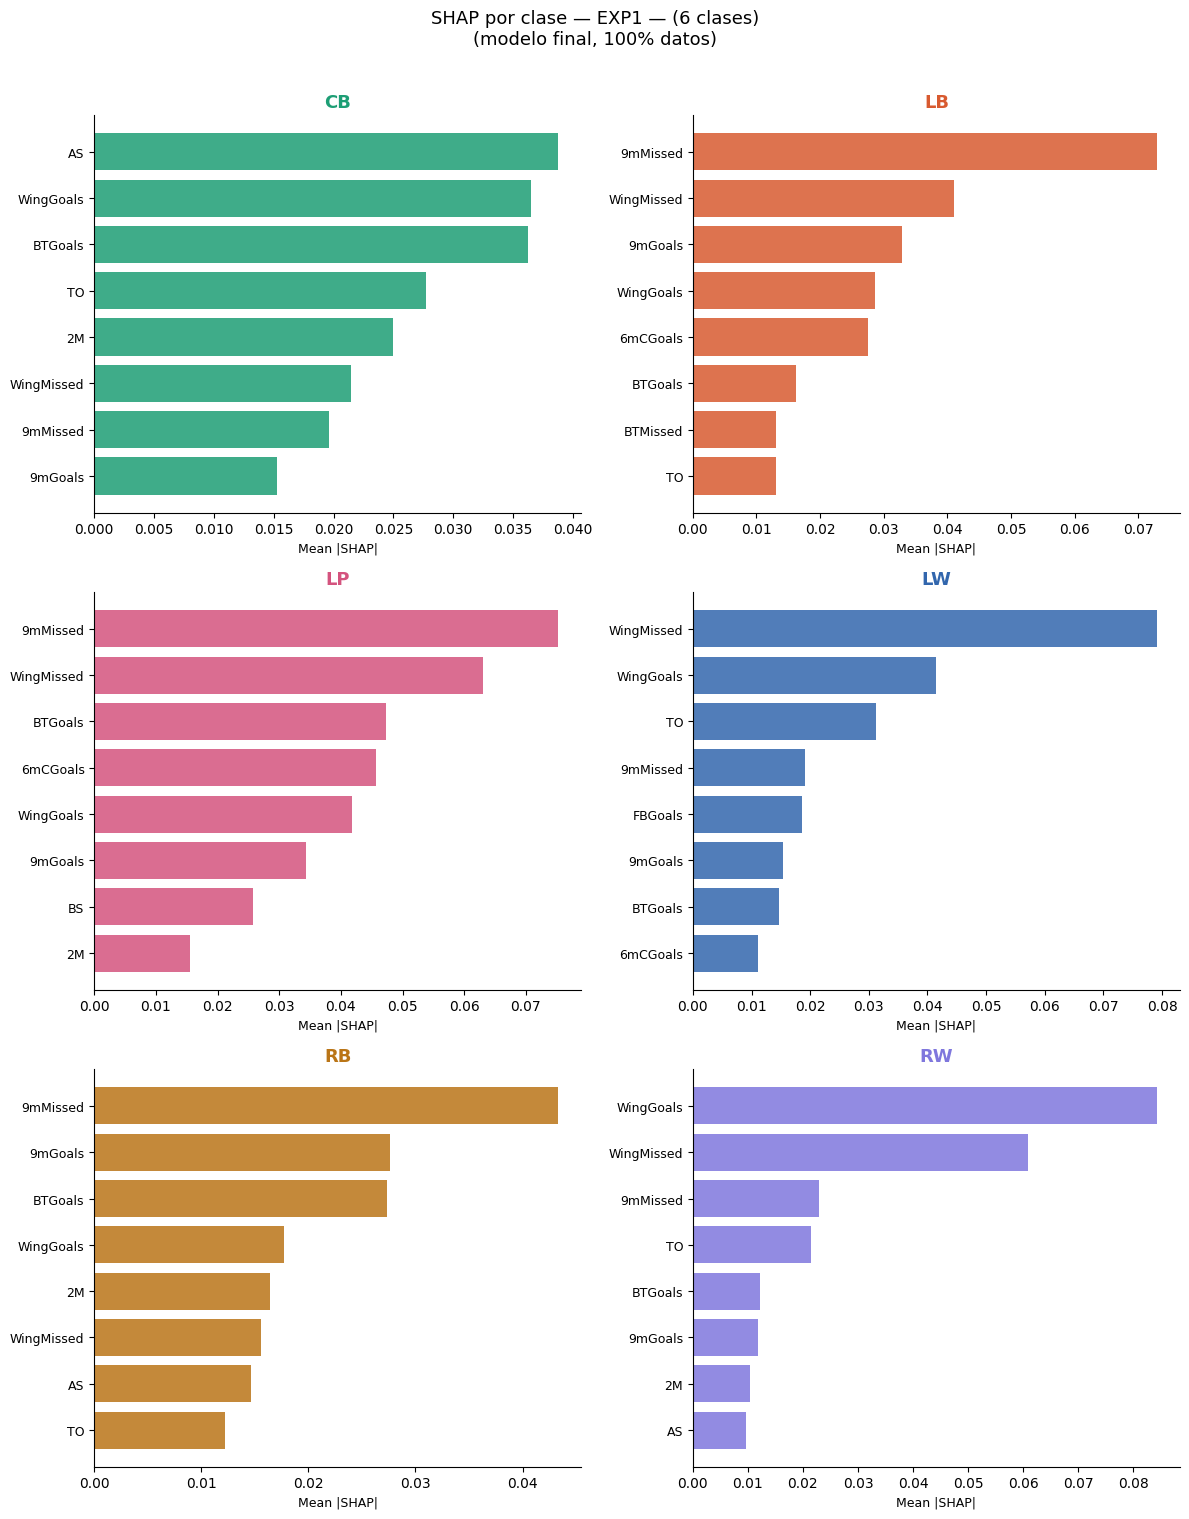

position_output/final/shap_exp1_final_per_class.png

=== SHAP EXP2 — Agrupado (4 clases) ===


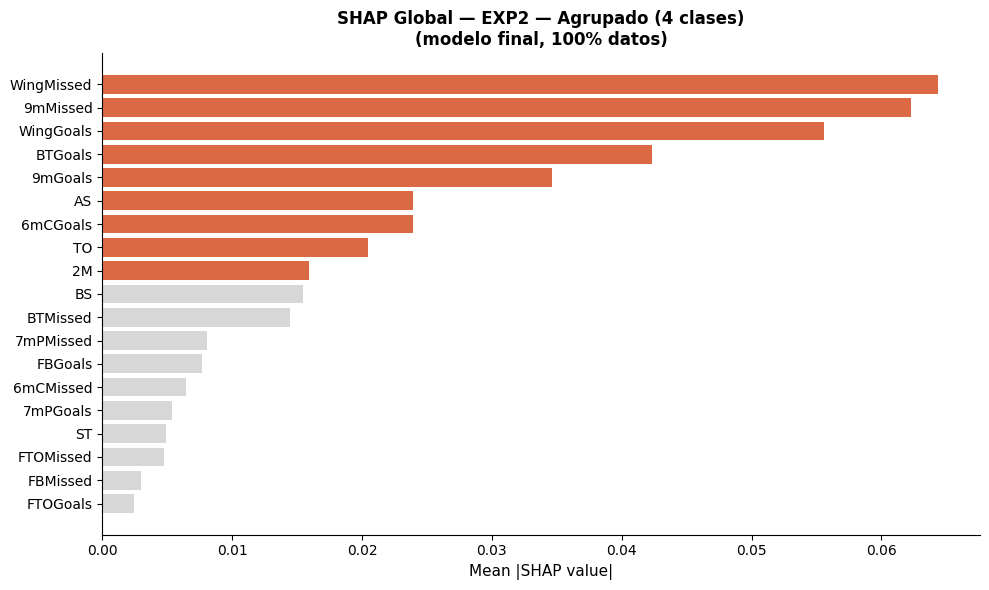

position_output/final/shap_exp2_final_global.png

Top 10 variables:


,mean_abs_shap
WingMissed,0.0644
9mMissed,0.0623
WingGoals,0.0556
BTGoals,0.0423
9mGoals,0.0347
AS,0.0239
6mCGoals,0.0239
TO,0.0204
2M,0.0159
BS,0.0155


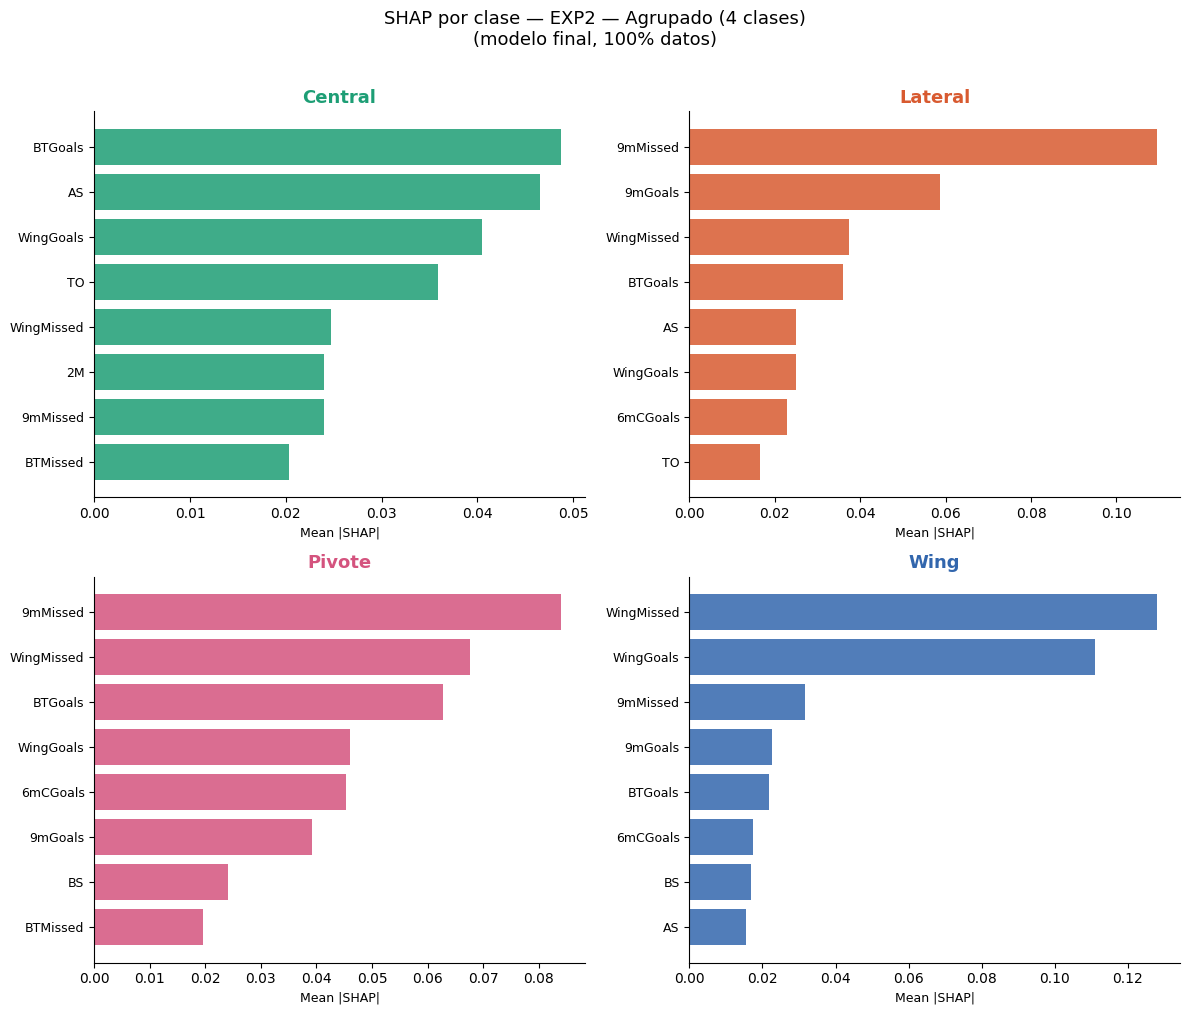

position_output/final/shap_exp2_final_per_class.png


In [298]:
# ── SHAP sobre modelos finales ───────────────────────────────
finals = []
if not SOLO_EXP2:
    finals.append(('EXP1 — (6 clases)', rf1_final, scaler1_final,
                   df_exp1, FEATURE_COLS, TARGET_COL, le1,
                   f'{OUT_ROOT}/final/shap_exp1_final', '#3266ad'))
finals.append(('EXP2 — Agrupado (4 clases)', rf2_final, scaler2_final,
               df_exp2, FEATURE_COLS, 'Grupo', le2,
               f'{OUT_ROOT}/final/shap_exp2_final', '#d85a30'))

for title, model, scaler, df, feat_cols, target_col, le, out_prefix, color in finals:
    print(f'\n=== SHAP {title} ===')

    X_all = scaler.transform(df[feat_cols].values)
    y_all = le.transform(df[target_col].values)

    explainer = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_all)

    # ── Importancia global (mean |SHAP|) ────────────────────
    if isinstance(shap_vals, list):
        global_imp = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    elif shap_vals.ndim == 3:
        global_imp = np.abs(shap_vals).mean(axis=(0, 2))
    else:
        global_imp = np.abs(shap_vals).mean(axis=0)

    shap_imp = pd.Series(global_imp, index=feat_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bar = [color if v > shap_imp.median() else '#d3d3d3' for v in shap_imp.values]
    ax.barh(shap_imp.index[::-1], shap_imp.values[::-1], color=colors_bar[::-1], alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'SHAP Global — {title}\n(modelo final, 100% datos)', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{out_prefix}_global.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'{out_prefix}_global.png')

    print('\nTop 10 variables:')
    display(shap_imp.head(10).to_frame('mean_abs_shap').round(4))

    # ── SHAP por clase ───────────────────────────────────────
    if isinstance(shap_vals, list):
        shap_list = shap_vals
    elif shap_vals.ndim == 3:
        shap_list = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]
    else:
        shap_list = [shap_vals]

    classes  = le.classes_
    n_cls    = len(classes)
    n_cols   = min(n_cls, 2)
    n_rows   = math.ceil(n_cls / n_cols)
    TOP_N    = 8

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes = np.array(axes).flatten()

    for idx, cls in enumerate(classes):
        sv       = shap_list[idx]
        mean_abs = np.abs(sv).mean(axis=0)
        top_vars = pd.Series(mean_abs, index=feat_cols).sort_values(ascending=False).head(TOP_N)
        cls_color = POS_COLORS.get(cls, color)
        ax = axes[idx]
        ax.barh(range(TOP_N), top_vars.values[::-1], color=cls_color, alpha=0.85)
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.set_title(cls, fontsize=13, fontweight='bold', color=cls_color)
        ax.spines[['top', 'right']].set_visible(False)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'SHAP por clase — {title}\n(modelo final, 100% datos)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{out_prefix}_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_prefix}_per_class.png')